# 🏠 House Prices — Professional Exploratory Data Analysis

## Project Goal
This notebook performs a structured **Exploratory Data Analysis (EDA)** of the House Prices dataset.

The objective is not only to visualize the data, but to move through:

**Observation → Interpretation → Decision**

The analysis covers:
- Dataset structure and data quality
- Missing-value analysis
- Duplicate analysis
- Numerical and categorical variables
- Outlier detection
- Skewness analysis and transformation
- Target-variable analysis
- Correlation and multicollinearity
- Statistical tests
- Feature engineering recommendations
- Final EDA conclusions and preprocessing plan

> **Important:** transformations that learn parameters from the data should ultimately be fitted only on the training set inside a proper preprocessing pipeline.

## 📚 Table of Contents

1. Import Libraries
2. Load and Inspect the Dataset
3. Data Quality Overview
4. Duplicate Analysis
5. Target Variable Analysis
6. Numerical Features
7. Skewness Analysis
8. Outlier Analysis
9. Missing Values — Count and Percentage
10. Structural Missing Values
11. Categorical Features
12. Ordinal Features
13. Target vs Categorical Features
14. Correlation Analysis
15. Multicollinearity and VIF
16. Time and Seasonality Analysis
17. Statistical Tests
18. Feature Engineering Recommendations
19. Final EDA Insights
20. Preprocessing Plan

## 1. Import Libraries

In [9]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 2. Load and Inspect the Dataset

In [10]:
import pandas as pd


url = "https://raw.githubusercontent.com/vbabashov/house-prices/refs/heads/main/data/raw/train.csv"
df = pd.read_csv(url)

df.head() 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Basic Structure

In [11]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

Shape: (1460, 81)

Data types:


,dtype
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
Street,object
Alley,object
LotShape,object
LandContour,object
Utilities,object



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null  

## 3. Data Quality Overview

In [12]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_%": df.isna().mean().mul(100),
    "n_unique": df.nunique()
}).sort_values("missing_%", ascending=False)

display(quality)

,dtype,missing_count,missing_%,n_unique
PoolQC,object,1453,99.521,3
MiscFeature,object,1406,96.301,4
Alley,object,1369,93.767,2
Fence,object,1179,80.753,4
MasVnrType,object,872,59.726,3
FireplaceQu,object,690,47.260,5
LotFrontage,float64,259,17.740,110
GarageYrBlt,float64,81,5.548,97
GarageCond,object,81,5.548,5
GarageType,object,81,5.548,6


### Numerical and Categorical Variables

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

display(pd.DataFrame({
    "Type": ["Numerical", "Categorical"],
    "Count": [len(numeric_cols), len(categorical_cols)]
}))

Numerical features: 38
Categorical features: 43


,Type,Count
0,Numerical,38
1,Categorical,43


## 4. Duplicate Analysis

In [14]:
duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)
print("Duplicate percentage:", f"{duplicate_count / len(df) * 100:.2f}%")

Number of duplicated rows: 0
Duplicate percentage: 0.00%


## 5. Target Variable Analysis

For the House Prices problem, the target is `SalePrice`.

We inspect:
- Central tendency
- Distribution
- Skewness
- Extreme values

In [15]:
target = "SalePrice"

display(df[target].describe())

target_skew = df[target].skew()

print(f"SalePrice skewness: {target_skew:.3f}")
print(f"Mean:   {df[target].mean():,.2f}")
print(f"Median: {df[target].median():,.2f}")

count     1,460.000
mean    180,921.196
std      79,442.503
min      34,900.000
25%     129,975.000
50%     163,000.000
75%     214,000.000
max     755,000.000
Name: SalePrice, dtype: float64

SalePrice skewness: 1.883
Mean:   180,921.20
Median: 163,000.00


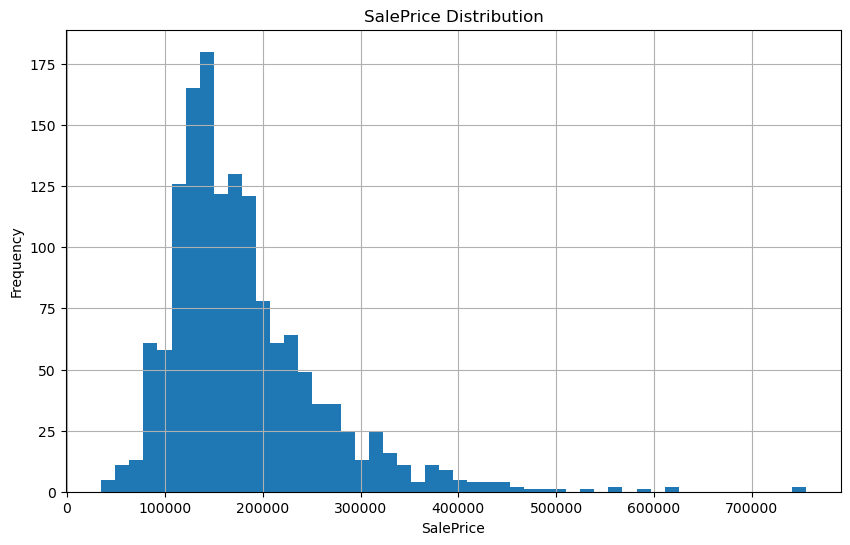

In [16]:
fig, ax = plt.subplots()
ax.hist(df[target].dropna(), bins=50)
ax.set_title("SalePrice Distribution")
ax.set_xlabel("SalePrice")
ax.set_ylabel("Frequency")
plt.show()

### Log Transformation of the Target

Original skewness: 1.883
Log-transformed skewness: 0.121


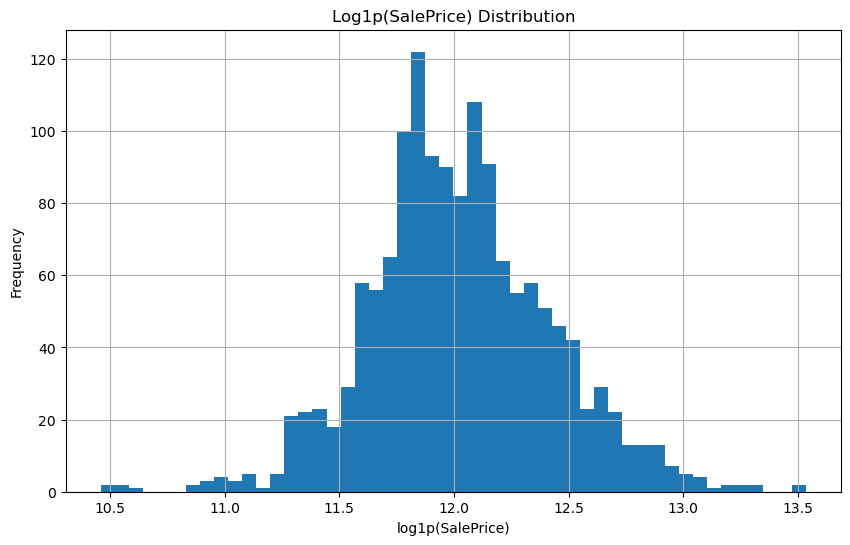

In [17]:
log_target = np.log1p(df[target])

print(f"Original skewness: {df[target].skew():.3f}")
print(f"Log-transformed skewness: {log_target.skew():.3f}")

fig, ax = plt.subplots()
ax.hist(log_target, bins=50)
ax.set_title("Log1p(SalePrice) Distribution")
ax.set_xlabel("log1p(SalePrice)")
ax.set_ylabel("Frequency")
plt.show()

### Interpretation
If `log1p(SalePrice)` is substantially less skewed, it is a strong candidate for the modeling target.

## 6. Numerical Features

In [18]:
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Id,"1,460.000",730.500,421.610,1.000,365.750,730.500,"1,095.250","1,460.000"
MSSubClass,"1,460.000",56.897,42.301,20.000,20.000,50.000,70.000,190.000
LotFrontage,"1,201.000",70.050,24.285,21.000,59.000,69.000,80.000,313.000
LotArea,"1,460.000","10,516.828","9,981.265","1,300.000","7,553.500","9,478.500","11,601.500","215,245.000"
OverallQual,"1,460.000",6.099,1.383,1.000,5.000,6.000,7.000,10.000
OverallCond,"1,460.000",5.575,1.113,1.000,5.000,5.000,6.000,9.000
YearBuilt,"1,460.000","1,971.268",30.203,"1,872.000","1,954.000","1,973.000","2,000.000","2,010.000"
YearRemodAdd,"1,460.000","1,984.866",20.645,"1,950.000","1,967.000","1,994.000","2,004.000","2,010.000"
MasVnrArea,"1,452.000",103.685,181.066,0.000,0.000,0.000,166.000,"1,600.000"
BsmtFinSF1,"1,460.000",443.640,456.098,0.000,0.000,383.500,712.250,"5,644.000"


### Numerical Distributions

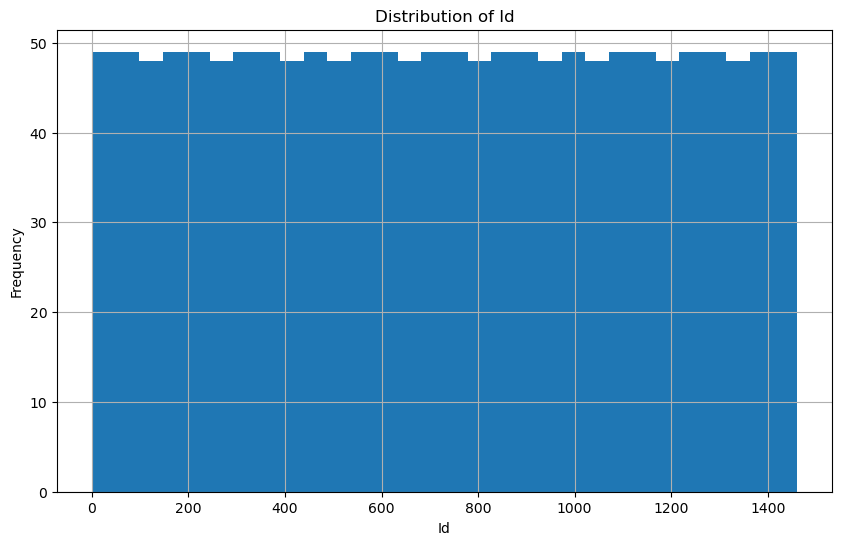

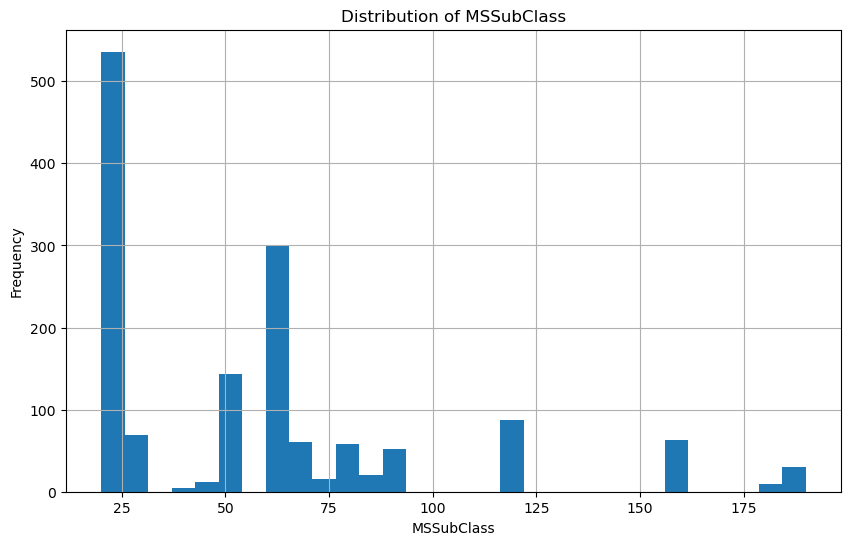

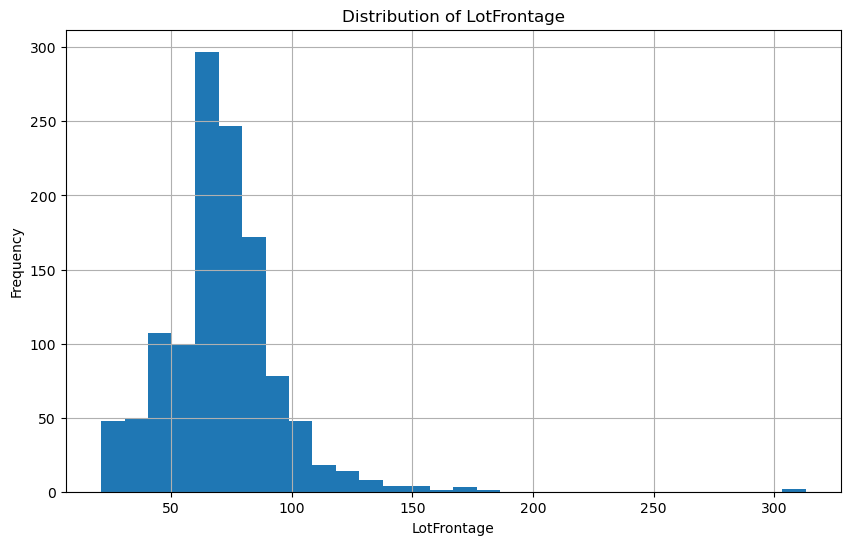

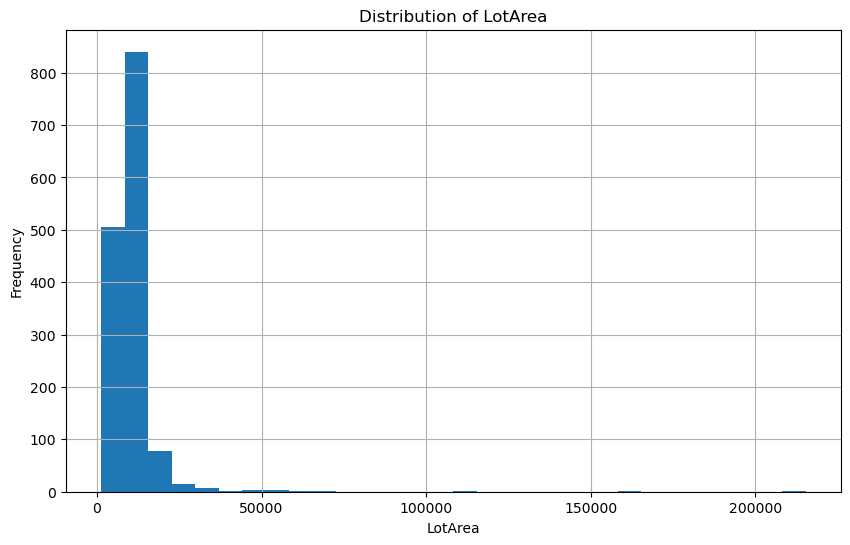

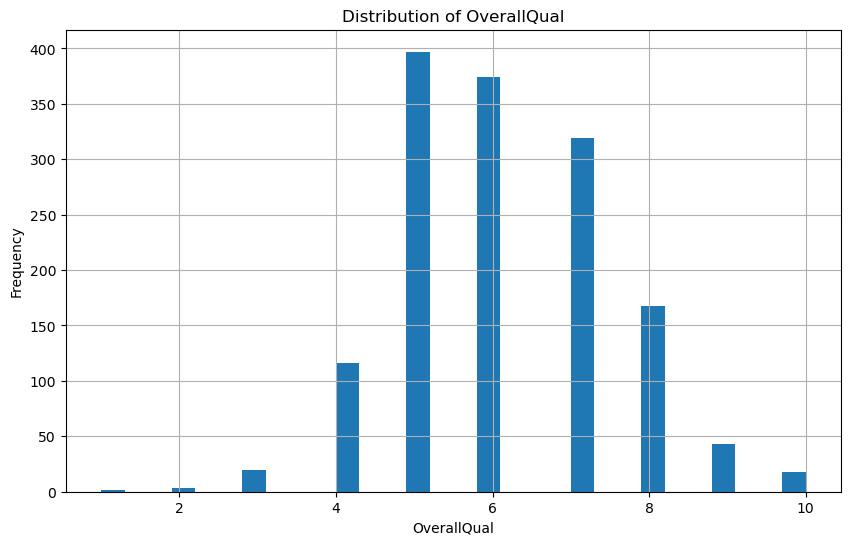

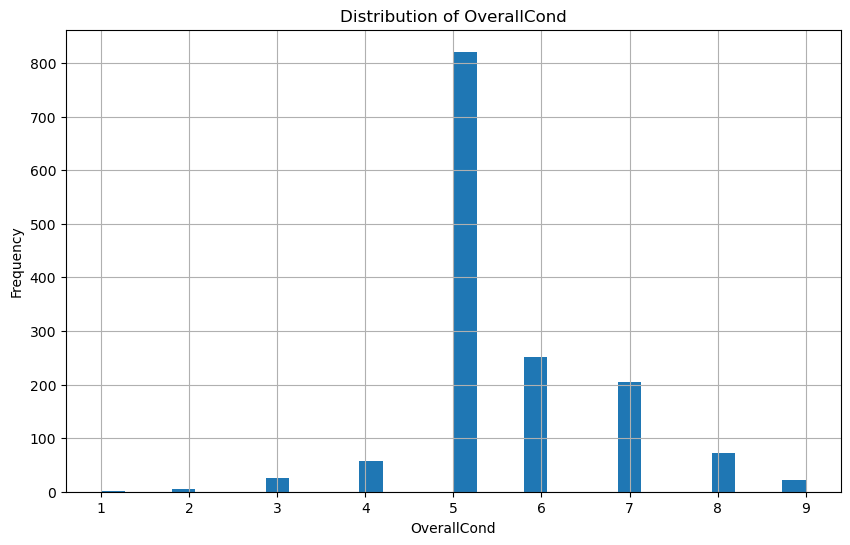

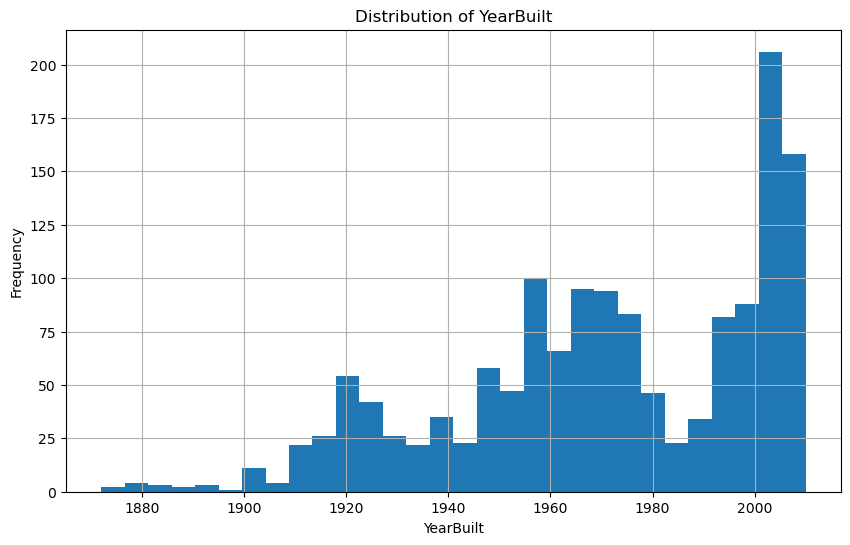

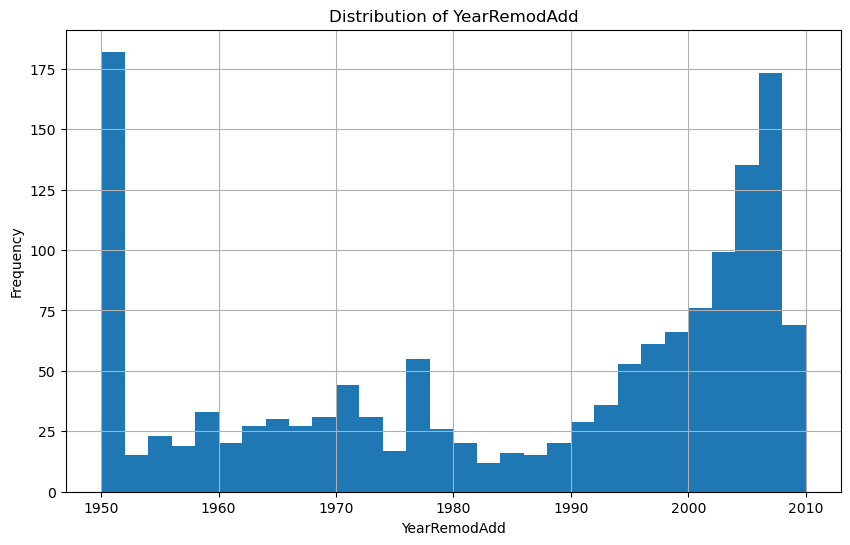

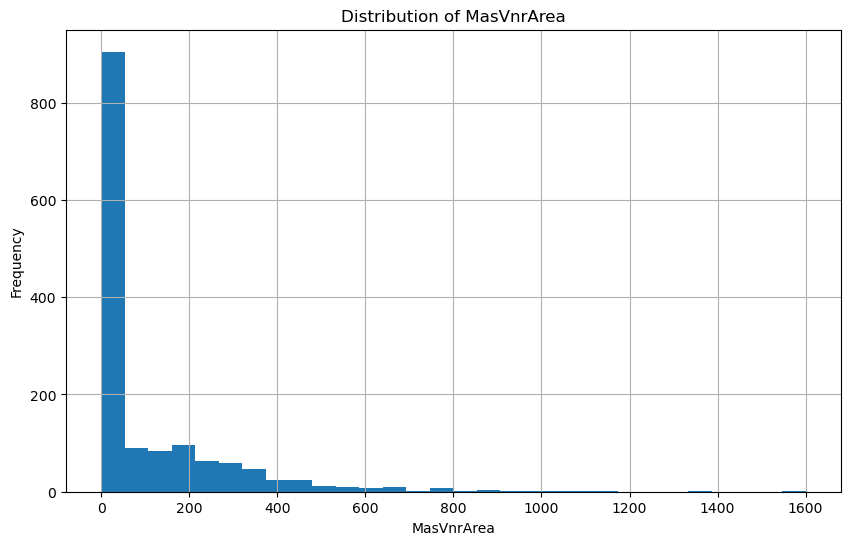

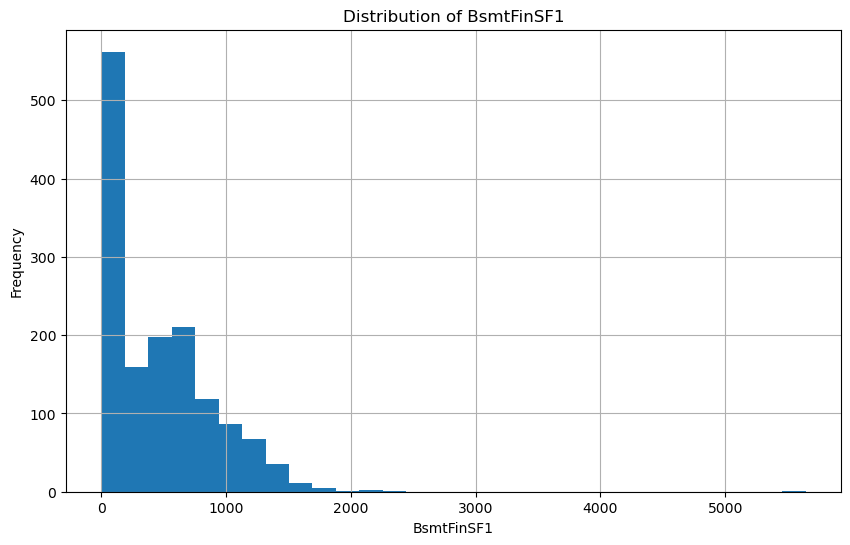

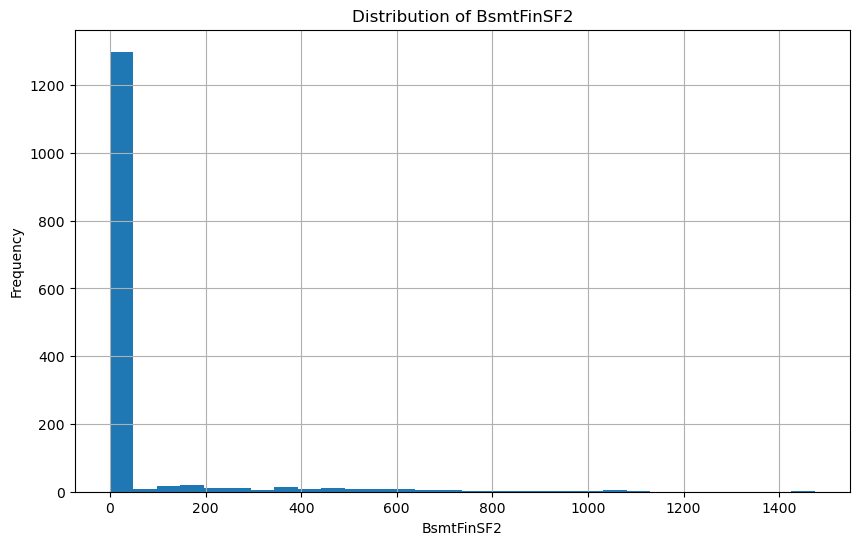

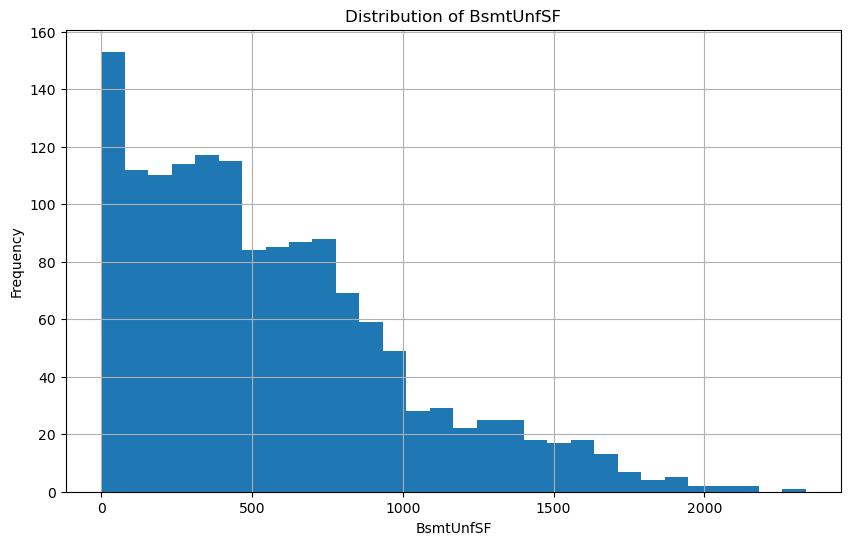

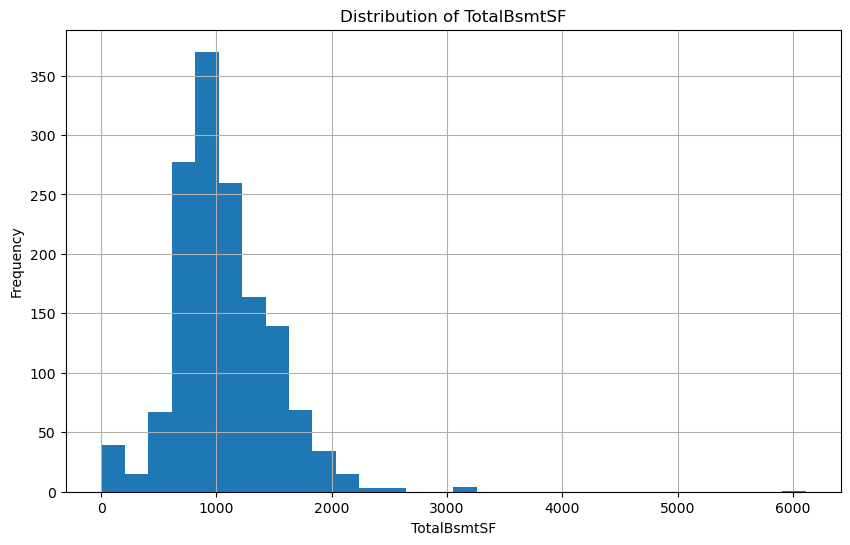

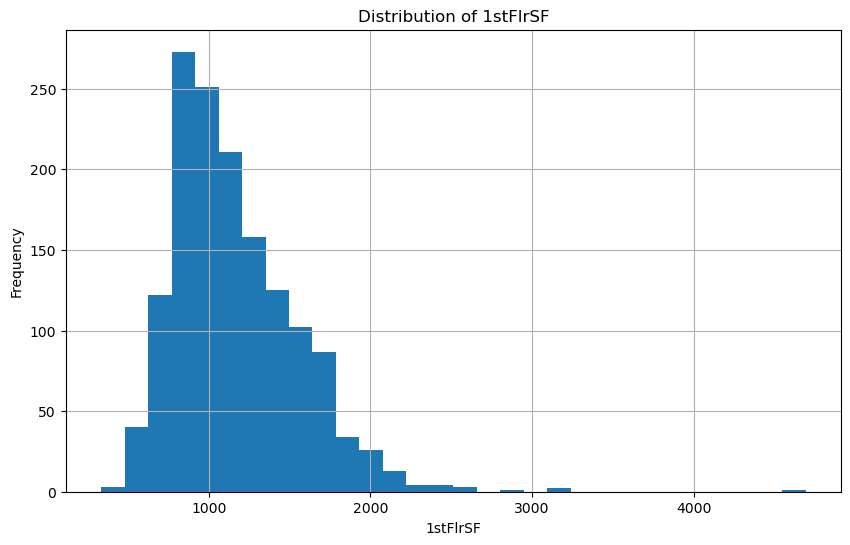

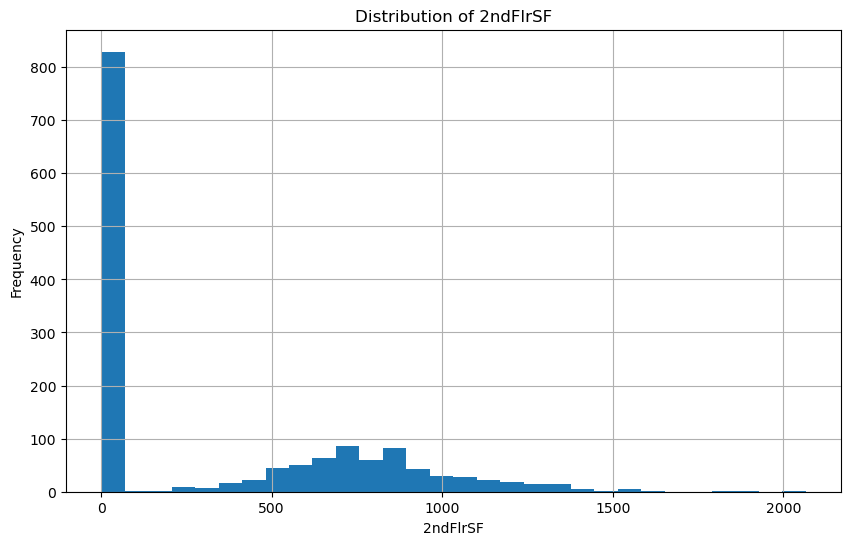

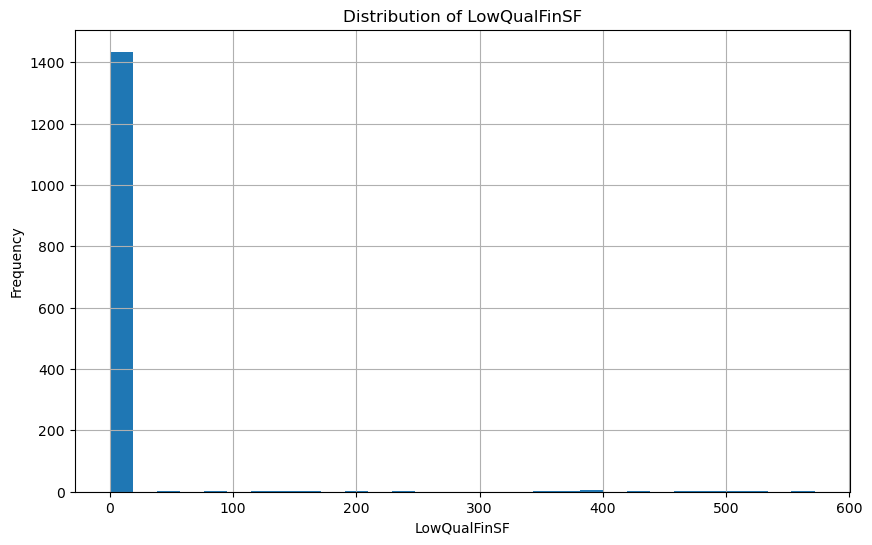

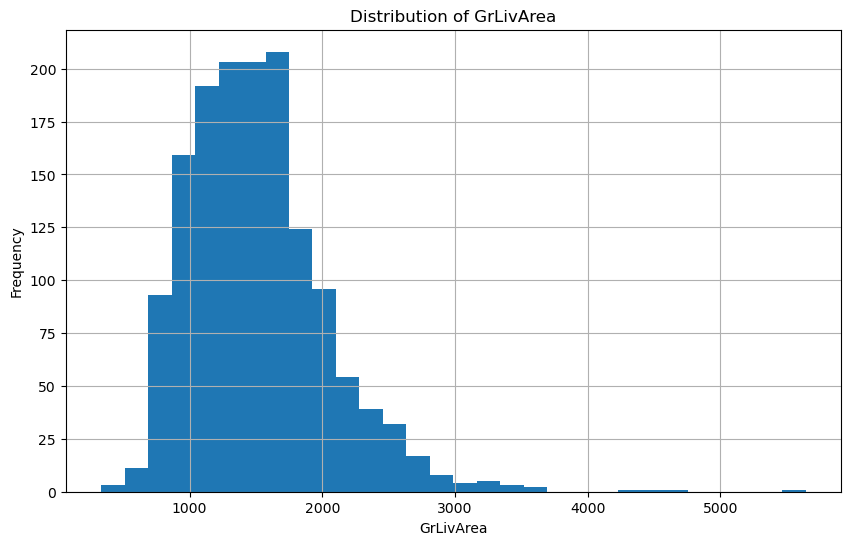

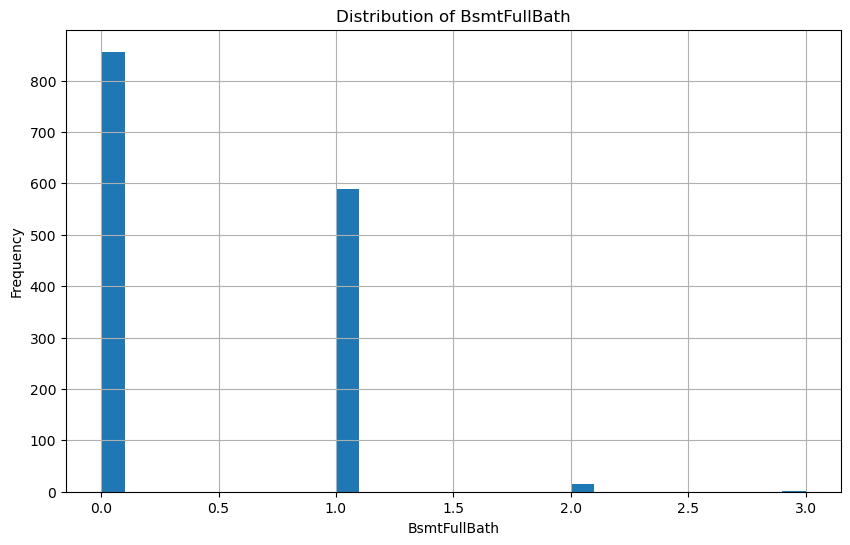

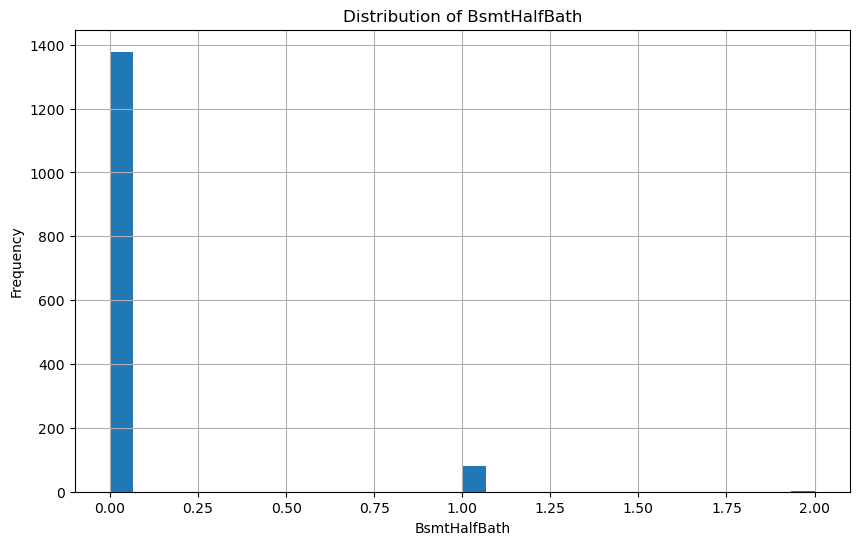

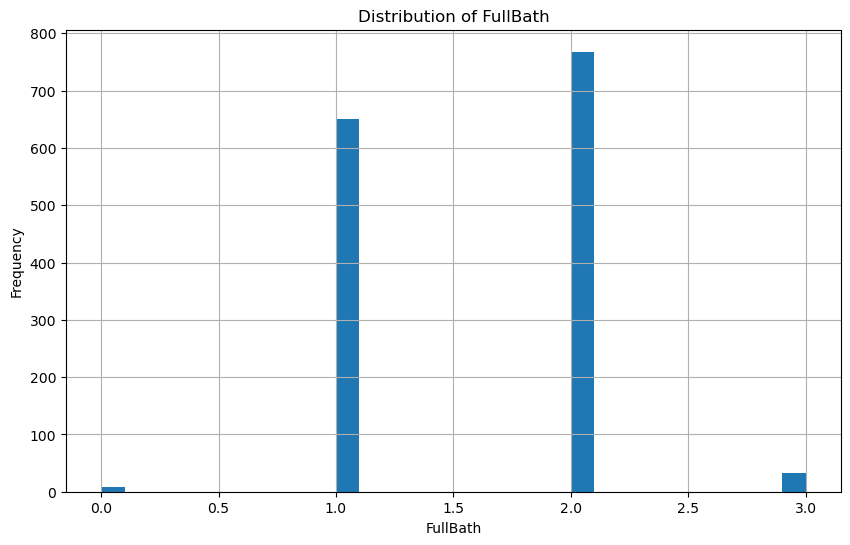

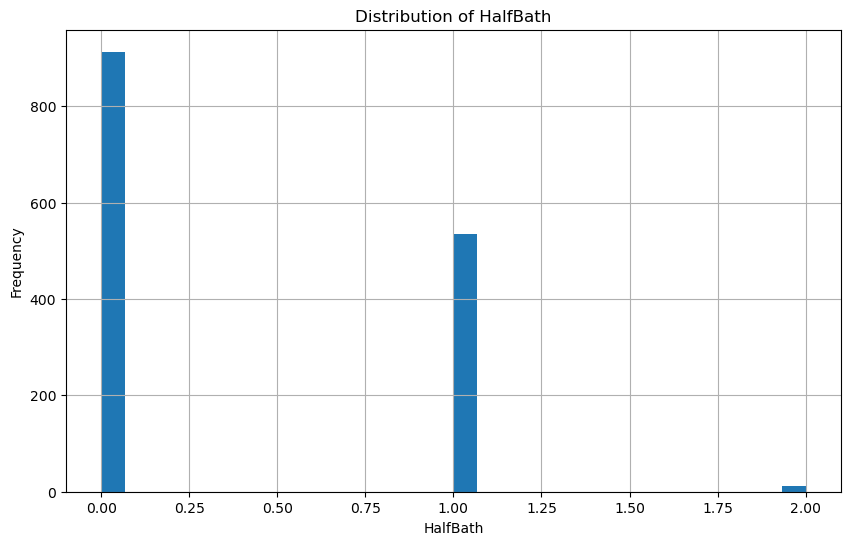

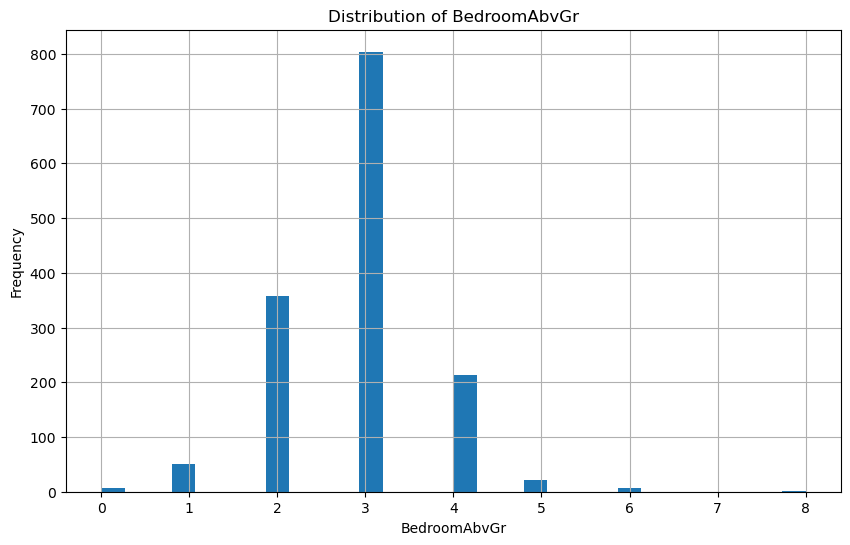

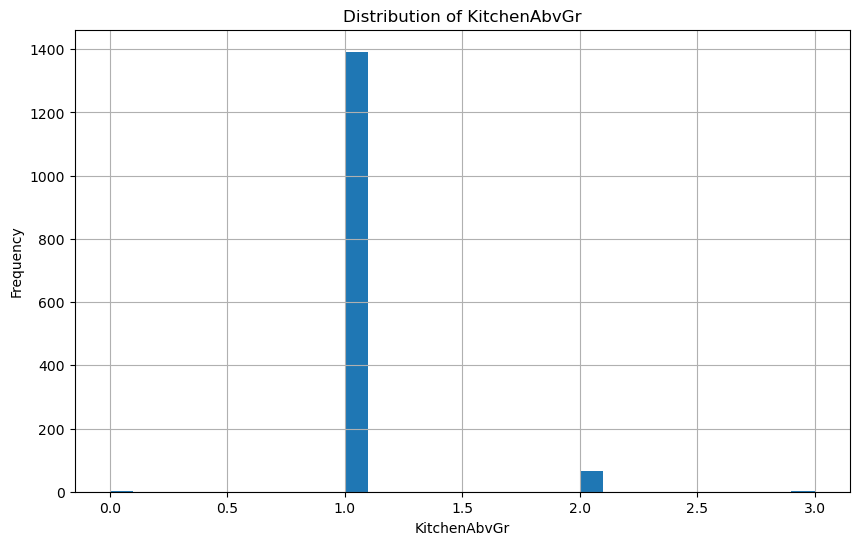

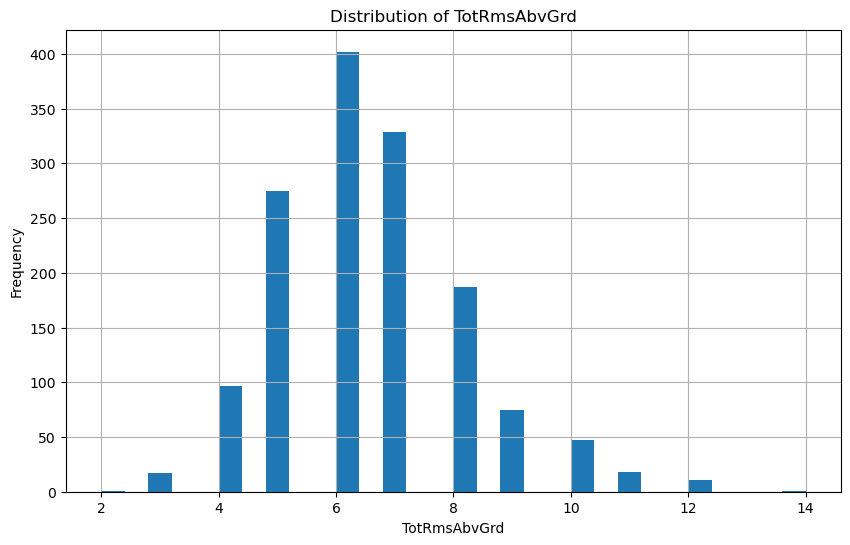

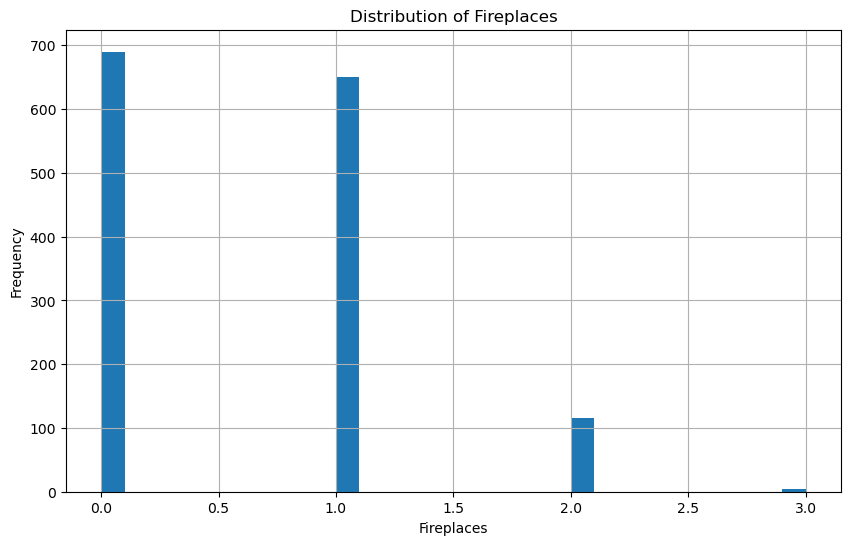

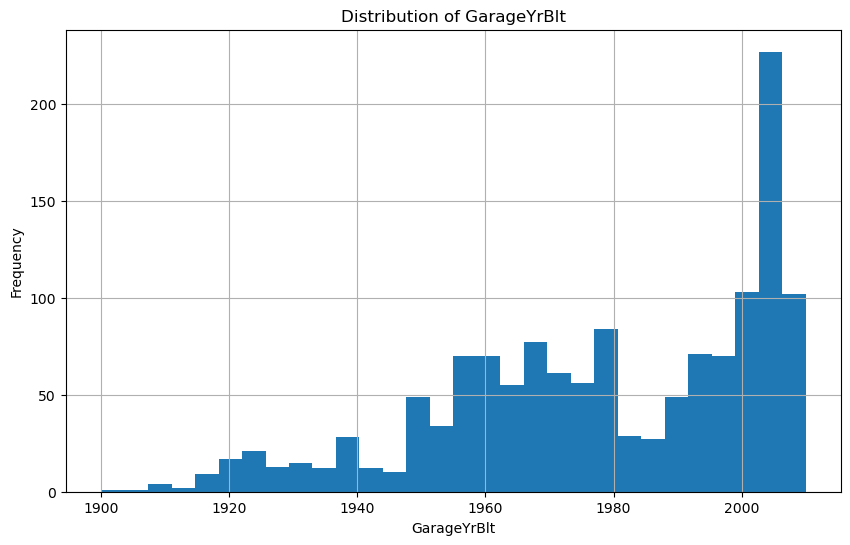

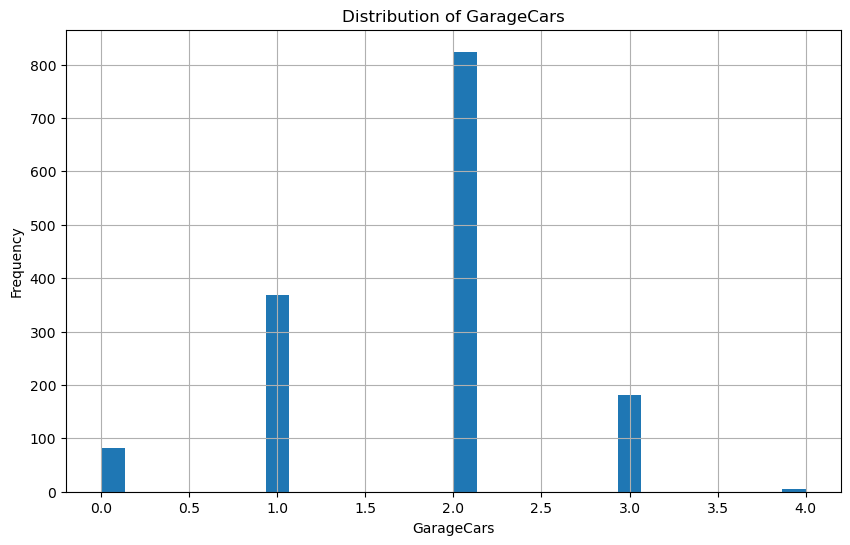

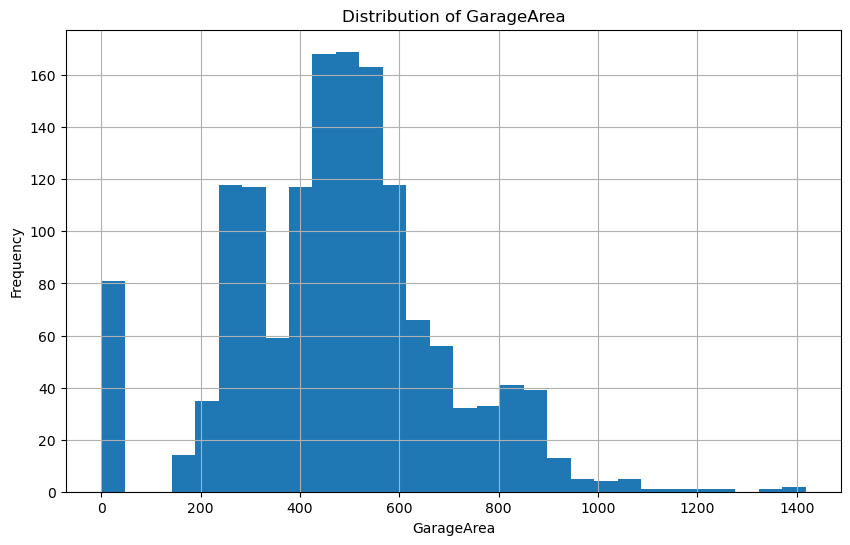

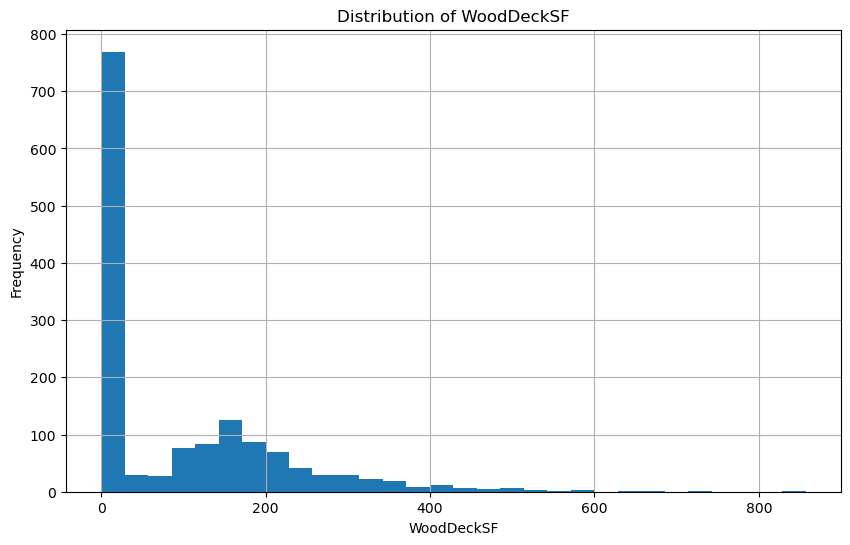

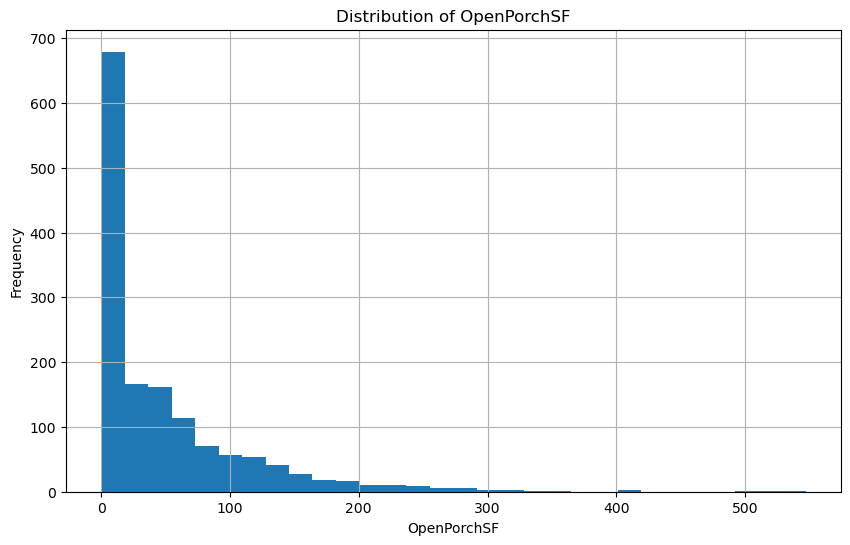

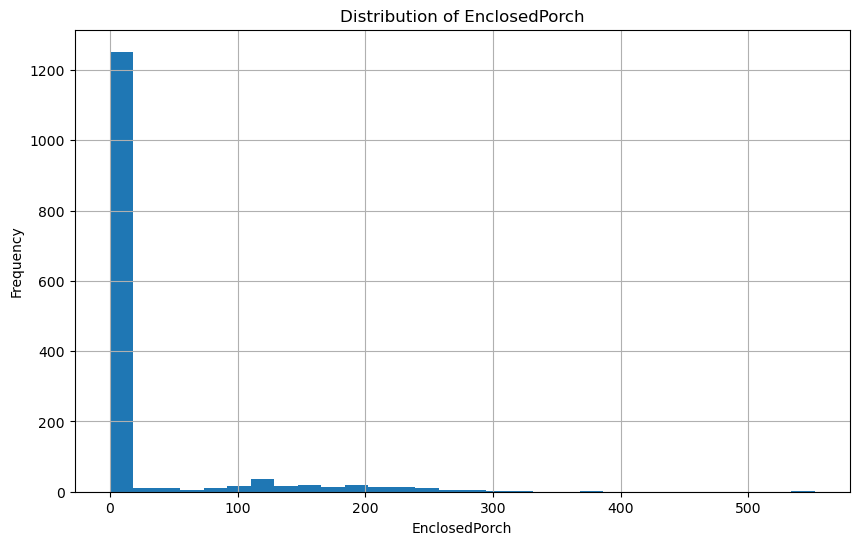

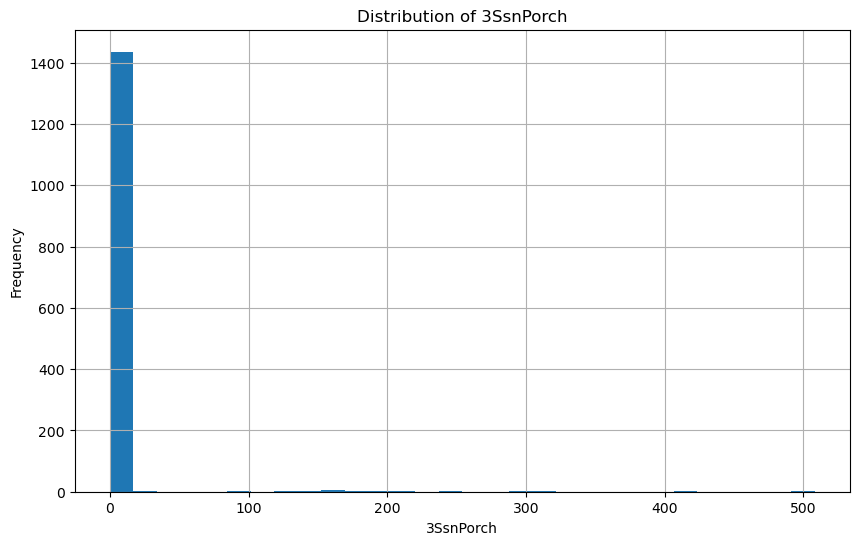

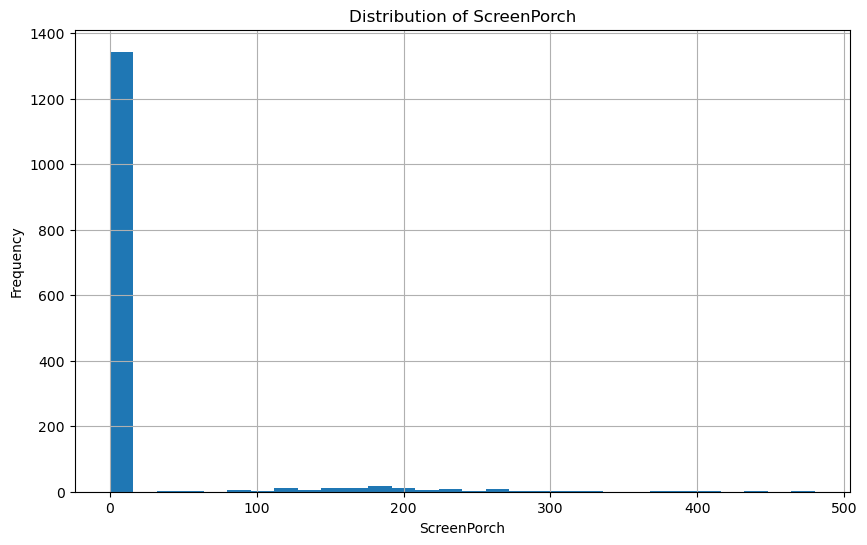

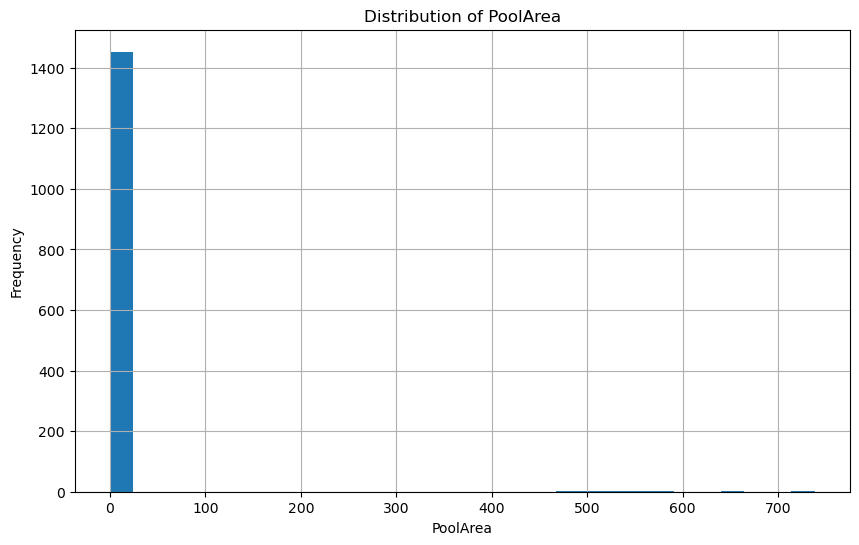

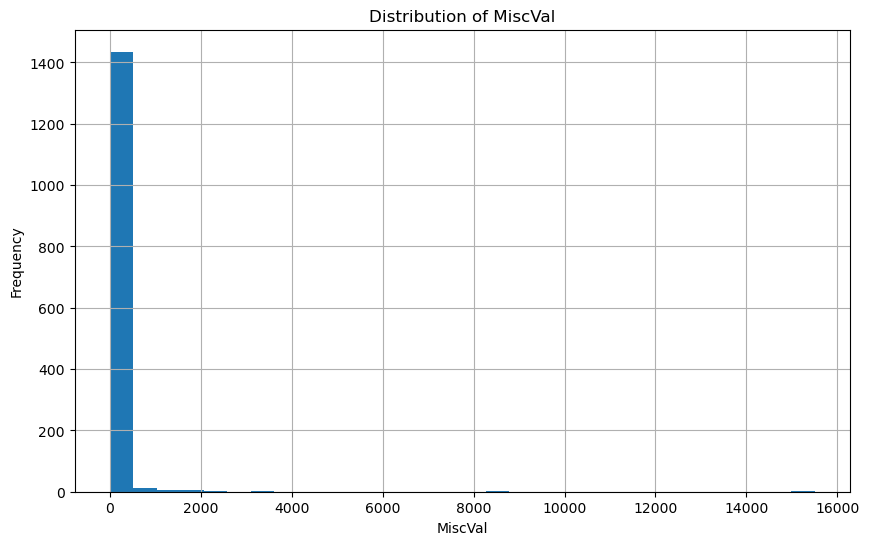

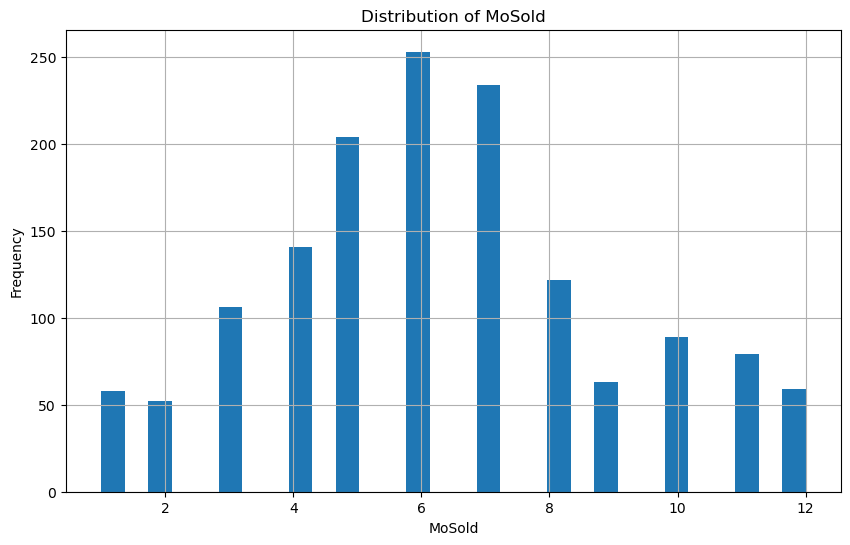

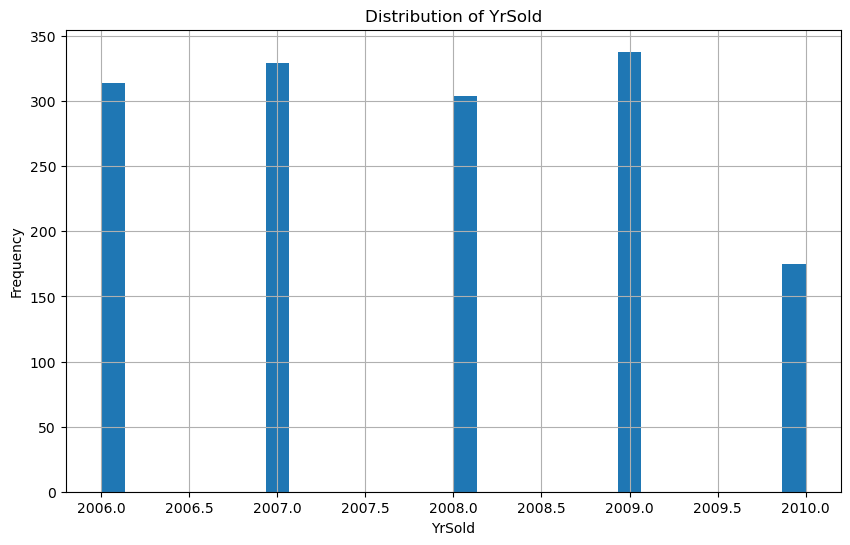

In [19]:
for col in numeric_cols:
    if col == target:
        continue

    fig, ax = plt.subplots()
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    plt.show()

## 7. Skewness Analysis

In [20]:
skewness_table = pd.DataFrame({
    "feature": numeric_cols,
    "skewness": [df[col].skew() for col in numeric_cols]
})

skewness_table["abs_skewness"] = skewness_table["skewness"].abs()
skewness_table["severity"] = pd.cut(
    skewness_table["abs_skewness"],
    bins=[-np.inf, 0.5, 1.0, 2.0, np.inf],
    labels=["Low", "Moderate", "High", "Very High"]
)

skewness_table = skewness_table.sort_values("abs_skewness", ascending=False)

display(skewness_table)

,feature,skewness,abs_skewness,severity
34,MiscVal,24.477,24.477,Very High
33,PoolArea,14.828,14.828,Very High
3,LotArea,12.208,12.208,Very High
31,3SsnPorch,10.304,10.304,Very High
15,LowQualFinSF,9.011,9.011,Very High
22,KitchenAbvGr,4.488,4.488,Very High
10,BsmtFinSF2,4.255,4.255,Very High
32,ScreenPorch,4.122,4.122,Very High
18,BsmtHalfBath,4.103,4.103,Very High
30,EnclosedPorch,3.090,3.090,Very High


### Skewness Interpretation

Practical screening guidelines:
- `|skew| < 0.5` → relatively symmetric
- `0.5 ≤ |skew| < 1` → moderate
- `1 ≤ |skew| < 2` → high
- `|skew| ≥ 2` → very high

These are screening guidelines, not strict laws.

In [21]:
skewed_features = skewness_table.loc[
    skewness_table["abs_skewness"] > 0.75, "feature"
].tolist()

print("Candidate features for transformation:")
print(skewed_features)

Candidate features for transformation:
['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath', 'EnclosedPorch', 'MasVnrArea', 'OpenPorchSF', 'LotFrontage', 'SalePrice', 'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF', 'MSSubClass', '1stFlrSF', 'GrLivArea', 'BsmtUnfSF', '2ndFlrSF']


### Log Transformation Check for Non-Negative Skewed Features

In [22]:
positive_skewed = [
    col for col in skewed_features
    if (df[col].dropna() >= 0).all()
]

comparison = []

for col in positive_skewed:
    original = df[col].skew()
    transformed = np.log1p(df[col]).skew()

    comparison.append({
        "feature": col,
        "original_skew": original,
        "log1p_skew": transformed,
        "absolute_reduction": abs(original) - abs(transformed)
    })

skew_comparison = pd.DataFrame(comparison).sort_values(
    "absolute_reduction", ascending=False
)

display(skew_comparison)

,feature,original_skew,log1p_skew,absolute_reduction
0,MiscVal,24.477,5.171,19.306
2,LotArea,12.208,-0.137,12.070
3,3SsnPorch,10.304,7.735,2.569
11,OpenPorchSF,2.364,-0.023,2.341
10,MasVnrArea,2.669,0.494,2.175
13,SalePrice,1.883,0.121,1.762
6,BsmtFinSF2,4.255,2.524,1.732
4,LowQualFinSF,9.011,7.460,1.551
12,LotFrontage,2.164,-0.729,1.435
15,WoodDeckSF,1.541,0.154,1.388


## 8. Outlier Analysis

In [23]:
outlier_rows = []

for col in numeric_cols:
    series = df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)

    outlier_rows.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": mask.sum(),
        "outlier_%": mask.mean() * 100
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values(
    "outlier_%", ascending=False
)

display(outlier_summary)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_%
30,EnclosedPorch,0.000,0.000,0.000,0.000,0.000,208,14.247
10,BsmtFinSF2,0.000,0.000,0.000,0.000,0.000,167,11.438
5,OverallCond,5.000,6.000,1.000,3.500,7.500,125,8.562
32,ScreenPorch,0.000,0.000,0.000,0.000,0.000,116,7.945
1,MSSubClass,20.000,70.000,50.000,-55.000,145.000,103,7.055
8,MasVnrArea,0.000,166.000,166.000,-249.000,415.000,96,6.575
2,LotFrontage,59.000,80.000,21.000,27.500,111.500,88,6.027
18,BsmtHalfBath,0.000,0.000,0.000,0.000,0.000,82,5.616
29,OpenPorchSF,0.000,68.000,68.000,-102.000,170.000,77,5.274
3,LotArea,"7,553.500","11,601.500","4,048.000","1,481.500","17,673.500",69,4.726


### Important: Outliers Are Not Automatically Errors

An observation outside the IQR boundaries is not necessarily wrong.

Before removing an outlier, ask:
1. Is it a data-entry error?
2. Is it physically impossible?
3. Is it a valid rare observation?
4. Does it have excessive influence on the target?
5. Does domain knowledge justify keeping/removing it?

For House Prices, extreme `GrLivArea` values should therefore be investigated rather than blindly deleted.

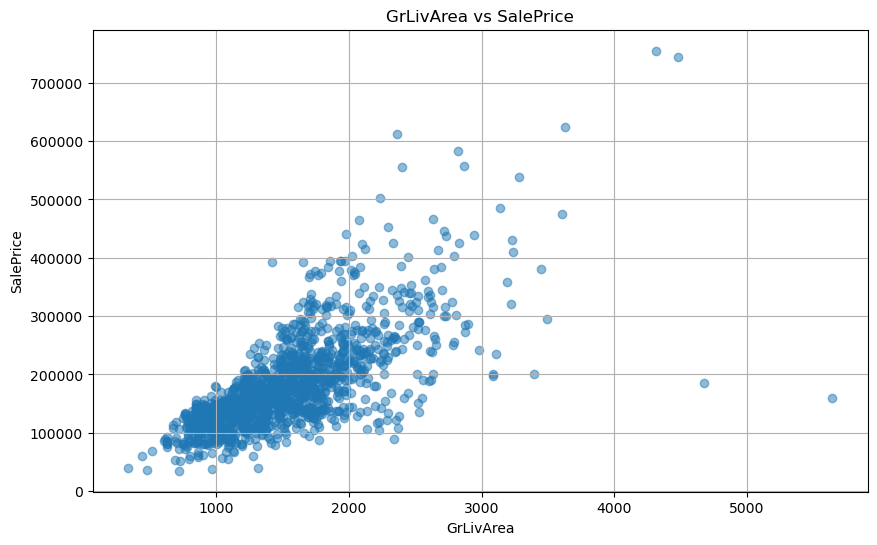

Observations with GrLivArea >= 4000:


,GrLivArea,SalePrice
1298,5642,160000
523,4676,184750
1182,4476,745000
691,4316,755000


In [24]:
if "GrLivArea" in df.columns:
    fig, ax = plt.subplots()
    ax.scatter(df["GrLivArea"], df[target], alpha=0.5)
    ax.set_title("GrLivArea vs SalePrice")
    ax.set_xlabel("GrLivArea")
    ax.set_ylabel("SalePrice")
    plt.show()

    extreme = df[df["GrLivArea"] >= 4000][["GrLivArea", target]]
    print("Observations with GrLivArea >= 4000:")
    display(extreme.sort_values("GrLivArea", ascending=False))

## 9. Missing Values — Count and Percentage

In [25]:
missing_summary = df.isna().sum().to_frame("missing_count")
missing_summary["missing_%"] = missing_summary["missing_count"] / len(df) * 100
missing_summary = missing_summary[missing_summary["missing_count"] > 0]     .sort_values("missing_%", ascending=False)

display(missing_summary)

,missing_count,missing_%
PoolQC,1453,99.521
MiscFeature,1406,96.301
Alley,1369,93.767
Fence,1179,80.753
MasVnrType,872,59.726
FireplaceQu,690,47.260
LotFrontage,259,17.740
GarageType,81,5.548
GarageYrBlt,81,5.548
GarageFinish,81,5.548


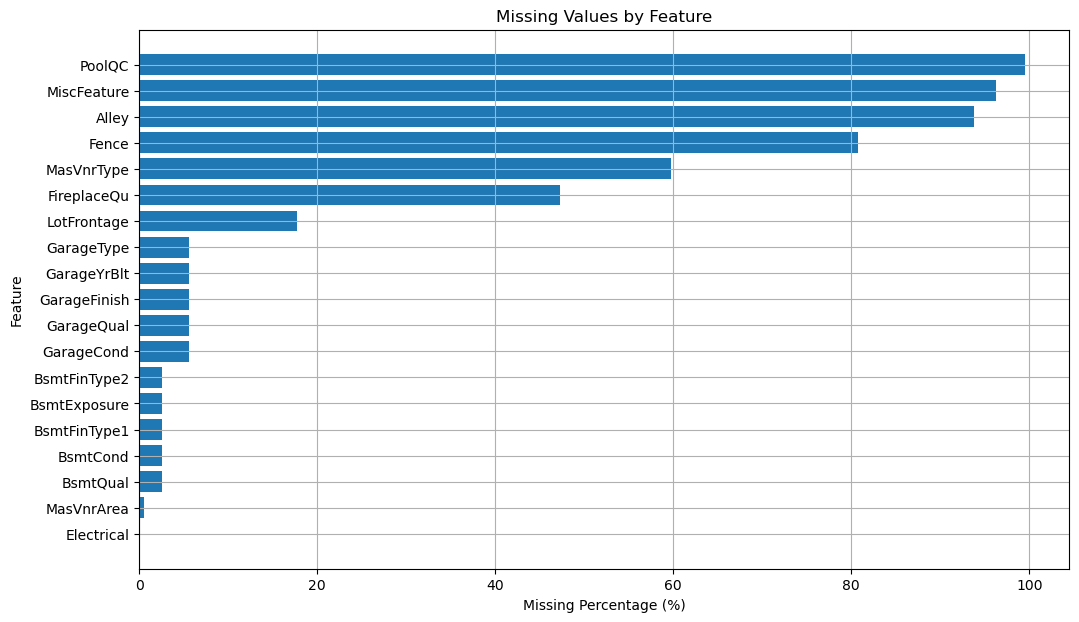

In [26]:
if not missing_summary.empty:
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(
        missing_summary.index[::-1],
        missing_summary["missing_%"][::-1]
    )
    ax.set_title("Missing Values by Feature")
    ax.set_xlabel("Missing Percentage (%)")
    ax.set_ylabel("Feature")
    plt.show()

## 10. Structural Missing Values

In this dataset, some `NaN` values can mean **absence of a house feature**, rather than missing information.

Examples:
- No basement
- No garage
- No pool
- No fireplace
- No alley access
- No masonry veneer

Therefore, imputation must be based on the meaning of each feature, not simply `fillna(0)` for every column.

In [27]:
structural_missing_examples = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "MasVnrType"
]

available_structural = [c for c in structural_missing_examples if c in df.columns]

for col in available_structural:
    print(f"{col}: {df[col].isna().sum():,} missing ({df[col].isna().mean()*100:.2f}%)")

PoolQC: 1,453 missing (99.52%)
MiscFeature: 1,406 missing (96.30%)
Alley: 1,369 missing (93.77%)
Fence: 1,179 missing (80.75%)
FireplaceQu: 690 missing (47.26%)
GarageType: 81 missing (5.55%)
GarageFinish: 81 missing (5.55%)
GarageQual: 81 missing (5.55%)
GarageCond: 81 missing (5.55%)
BsmtQual: 37 missing (2.53%)
BsmtCond: 37 missing (2.53%)
BsmtExposure: 38 missing (2.60%)
BsmtFinType1: 37 missing (2.53%)
BsmtFinType2: 38 missing (2.60%)
MasVnrType: 872 missing (59.73%)


## 11. Categorical Features

In [28]:
for col in categorical_cols:
    print(f"\n{'='*70}\n{col}")
    print("Unique values:", df[col].nunique())
    display(df[col].value_counts(dropna=False).head(15).to_frame("count"))


MSZoning
Unique values: 5


,count
MSZoning,
RL,1151
RM,218
FV,65
RH,16
C (all),10



Street
Unique values: 2


,count
Street,
Pave,1454
Grvl,6



Alley
Unique values: 2


...

,count
MiscFeature,
NaN,1406
Shed,49
Gar2,2
Othr,2
TenC,1



SaleType
Unique values: 9


,count
SaleType,
WD,1267
New,122
COD,43
ConLD,9
ConLI,5
ConLw,5
CWD,4
Oth,3
Con,2



SaleCondition
Unique values: 6


,count
SaleCondition,
Normal,1198
Partial,125
Abnorml,101
Family,20
Alloca,12
AdjLand,4


### Class Imbalance / Dominant Categories

In [29]:
category_summary = []

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    top_category = counts.index[0]
    top_count = counts.iloc[0]

    category_summary.append({
        "feature": col,
        "unique_categories": df[col].nunique(dropna=False),
        "most_common_category": top_category,
        "most_common_count": top_count,
        "most_common_%": top_count / len(df) * 100
    })

category_summary = pd.DataFrame(category_summary).sort_values(
    "most_common_%", ascending=False
)

display(category_summary)

,feature,unique_categories,most_common_category,most_common_count,most_common_%
5,Utilities,2,AllPub,1459,99.932
1,Street,2,Pave,1454,99.589
38,PoolQC,4,NaN,1453,99.521
10,Condition2,8,Norm,1445,98.973
14,RoofMatl,8,CompShg,1434,98.219
26,Heating,6,GasA,1428,97.808
40,MiscFeature,5,NaN,1406,96.301
7,LandSlope,3,Gtl,1382,94.658
2,Alley,3,NaN,1369,93.767
28,CentralAir,2,Y,1365,93.493


## 12. Ordinal Features

In [30]:
ordinal_features = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
    "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"
]

ordinal_available = [c for c in ordinal_features if c in df.columns]

for col in ordinal_available:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False).to_frame("count"))


ExterQual


,count
ExterQual,
TA,906
Gd,488
Ex,52
Fa,14



ExterCond


,count
ExterCond,
TA,1282
Gd,146
Fa,28
Ex,3
Po,1



BsmtQual


...

,count
GarageQual,
TA,1311
NaN,81
Fa,48
Gd,14
Ex,3
Po,3



GarageCond


,count
GarageCond,
TA,1326
NaN,81
Fa,35
Gd,9
Po,7
Ex,2



PoolQC


,count
PoolQC,
NaN,1453
Gd,3
Ex,2
Fa,2


### Ordinal Encoding Recommendation

For genuinely ordered categories, preserve their order during preprocessing.

For example, quality levels can be mapped from poor → fair → typical → good → excellent.

Do **not** use arbitrary label encoding for nominal categories where no order exists.

## 13. Target vs Categorical Features

Countplots tell us how categories are distributed.

For prediction, we also need to ask:

> **How does SalePrice change across categories?**

Boxplots and grouped median/mean values are useful here.


OverallQual → SalePrice


,count,mean,median
OverallQual,,,
10,18,"438,588.389","432,390.000"
9,43,"367,513.023","345,000.000"
8,168,"274,735.536","269,750.000"
7,319,"207,716.423","200,141.000"
6,374,"161,603.035","160,000.000"
5,397,"133,523.348","133,000.000"
4,116,"108,420.655","108,000.000"
3,20,"87,473.750","86,250.000"
2,3,"51,770.333","60,000.000"


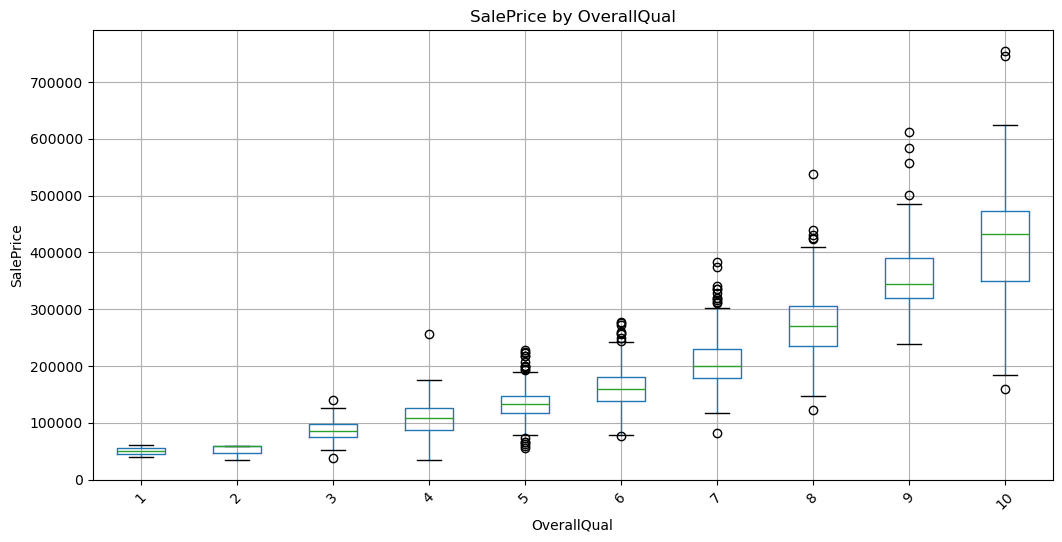


KitchenQual → SalePrice


,count,mean,median
KitchenQual,,,
Ex,100,"328,554.670","316,750.000"
Gd,586,"212,116.024","201,400.000"
TA,735,"139,962.512","137,000.000"
Fa,39,"105,565.205","115,000.000"


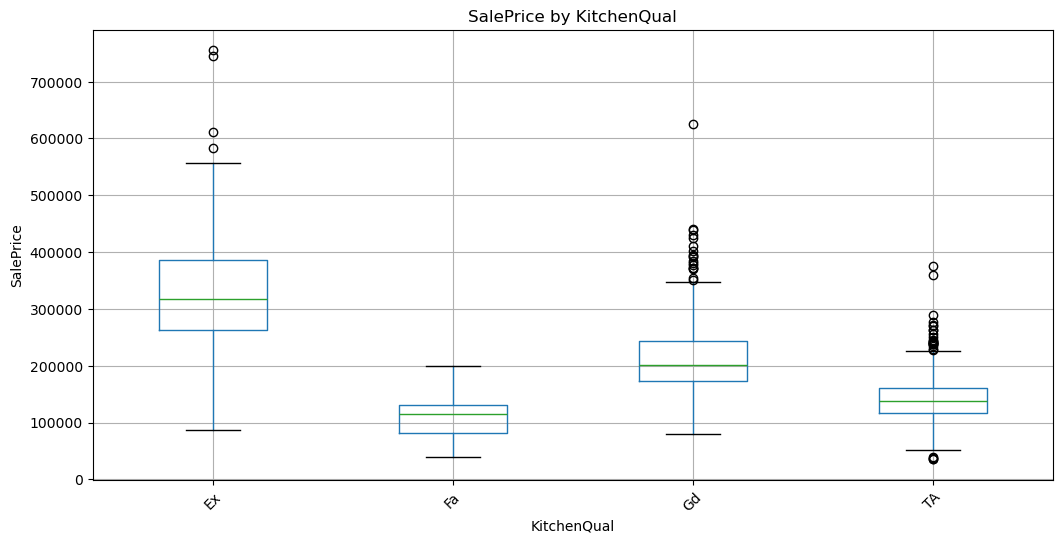


GarageType → SalePrice


,count,mean,median
GarageType,,,
BuiltIn,88,"254,751.739","227,500.000"
Attchd,870,"202,892.656","185,000.000"
2Types,6,"151,283.333","159,000.000"
Basment,19,"160,570.684","148,000.000"
Detchd,387,"134,091.163","129,500.000"
CarPort,9,"109,962.111","108,000.000"
NaN,81,"103,317.284","100,000.000"


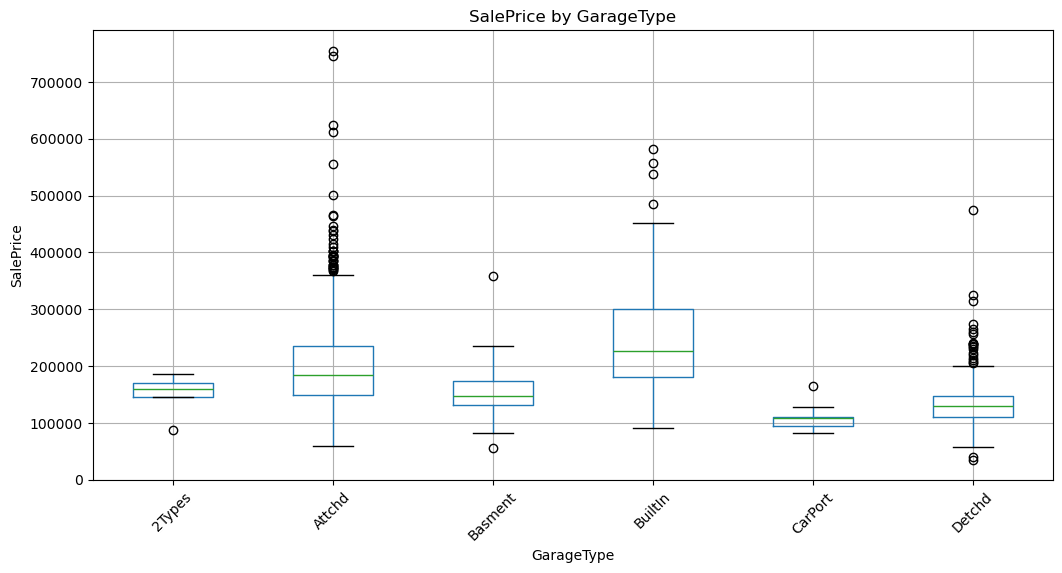


Foundation → SalePrice


,count,mean,median
Foundation,,,
PConc,647,"225,230.442","205,000.000"
Wood,3,"185,666.667","164,000.000"
CBlock,634,"149,805.715","141,500.000"
Stone,6,"165,959.167","126,500.000"
BrkTil,146,"132,291.075","125,250.000"
Slab,24,"107,365.625","104,150.000"


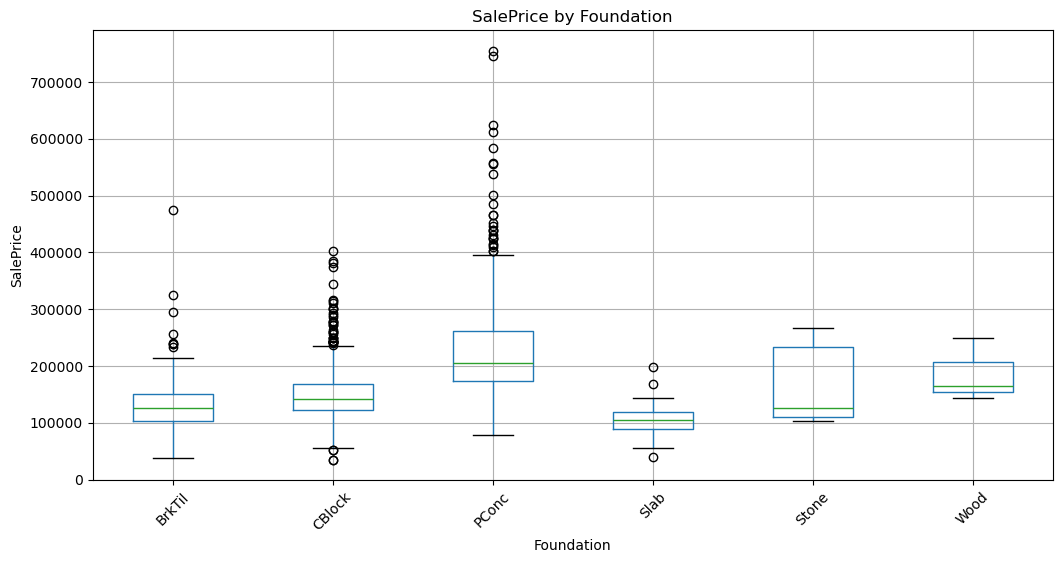


SaleCondition → SalePrice


,count,mean,median
SaleCondition,,,
Partial,125,"272,291.752","244,600.000"
Normal,1198,"175,202.220","160,000.000"
Alloca,12,"167,377.417","148,145.000"
Family,20,"149,600.000","140,500.000"
Abnorml,101,"146,526.624","130,000.000"
AdjLand,4,"104,125.000","104,000.000"


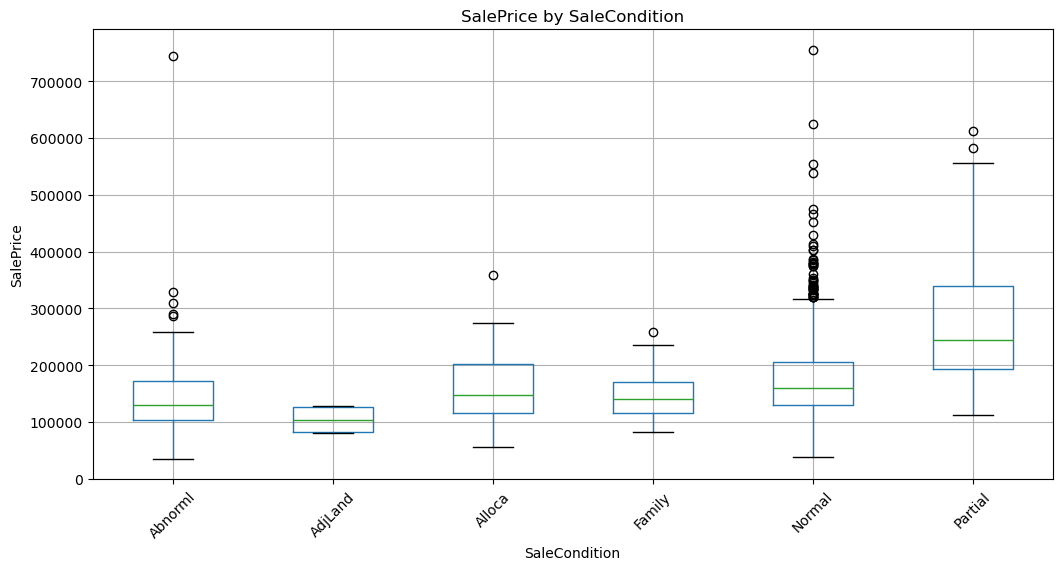


HouseStyle → SalePrice


,count,mean,median
HouseStyle,,,
2.5Fin,8,"220,000.000","194,000.000"
2Story,445,"210,051.764","190,000.000"
SLvl,65,"166,703.385","164,500.000"
1Story,726,"175,985.478","154,750.000"
SFoyer,37,"135,074.486","135,960.000"
2.5Unf,11,"157,354.545","133,900.000"
1.5Fin,154,"143,116.740","132,000.000"
1.5Unf,14,"110,150.000","111,250.000"


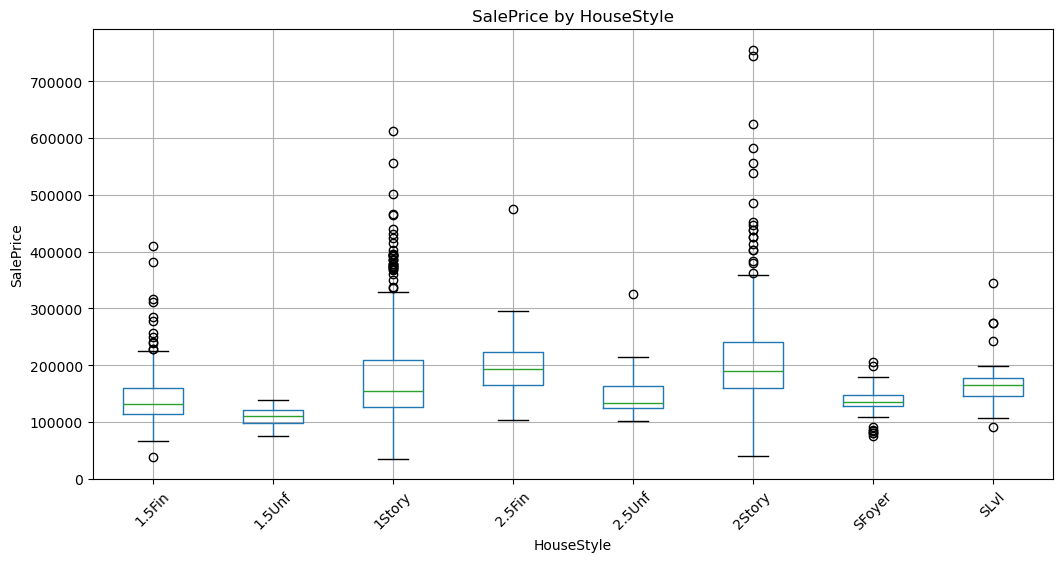

In [31]:
important_categorical = [
    "Neighborhood", "OverallQual", "KitchenQual",
    "GarageType", "Foundation", "SaleCondition", "HouseStyle"
]

available_target_cats = [c for c in important_categorical if c in df.columns]

for col in available_target_cats:
    if df[col].nunique(dropna=True) <= 20:
        grouped = df.groupby(col, dropna=False)[target].agg(
            ["count", "mean", "median"]
        ).sort_values("median", ascending=False)

        print(f"\n{col} → {target}")
        display(grouped)

        fig, ax = plt.subplots(figsize=(12, 6))
        df.boxplot(column=target, by=col, ax=ax)
        ax.set_title(f"{target} by {col}")
        ax.set_xlabel(col)
        ax.set_ylabel(target)
        plt.suptitle("")
        plt.xticks(rotation=45)
        plt.show()

## 14. Correlation Analysis

In [32]:
numeric_for_corr = df.select_dtypes(include=np.number)

corr_with_target = (
    numeric_for_corr.corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

display(corr_with_target.to_frame("correlation_with_SalePrice"))

,correlation_with_SalePrice
OverallQual,0.791
GrLivArea,0.709
GarageCars,0.640
GarageArea,0.623
TotalBsmtSF,0.614
1stFlrSF,0.606
FullBath,0.561
TotRmsAbvGrd,0.534
YearBuilt,0.523
YearRemodAdd,0.507


### Top Correlated Numerical Features

In [33]:
top_n = 15
top_corr_features = corr_with_target.head(top_n).index.tolist()

display(
    df[top_corr_features + [target]]
    .corr()[target]
    .sort_values(key=abs, ascending=False)
    .to_frame("correlation")
)

,correlation
SalePrice,1.000
OverallQual,0.791
GrLivArea,0.709
GarageCars,0.640
GarageArea,0.623
TotalBsmtSF,0.614
1stFlrSF,0.606
FullBath,0.561
TotRmsAbvGrd,0.534
YearBuilt,0.523


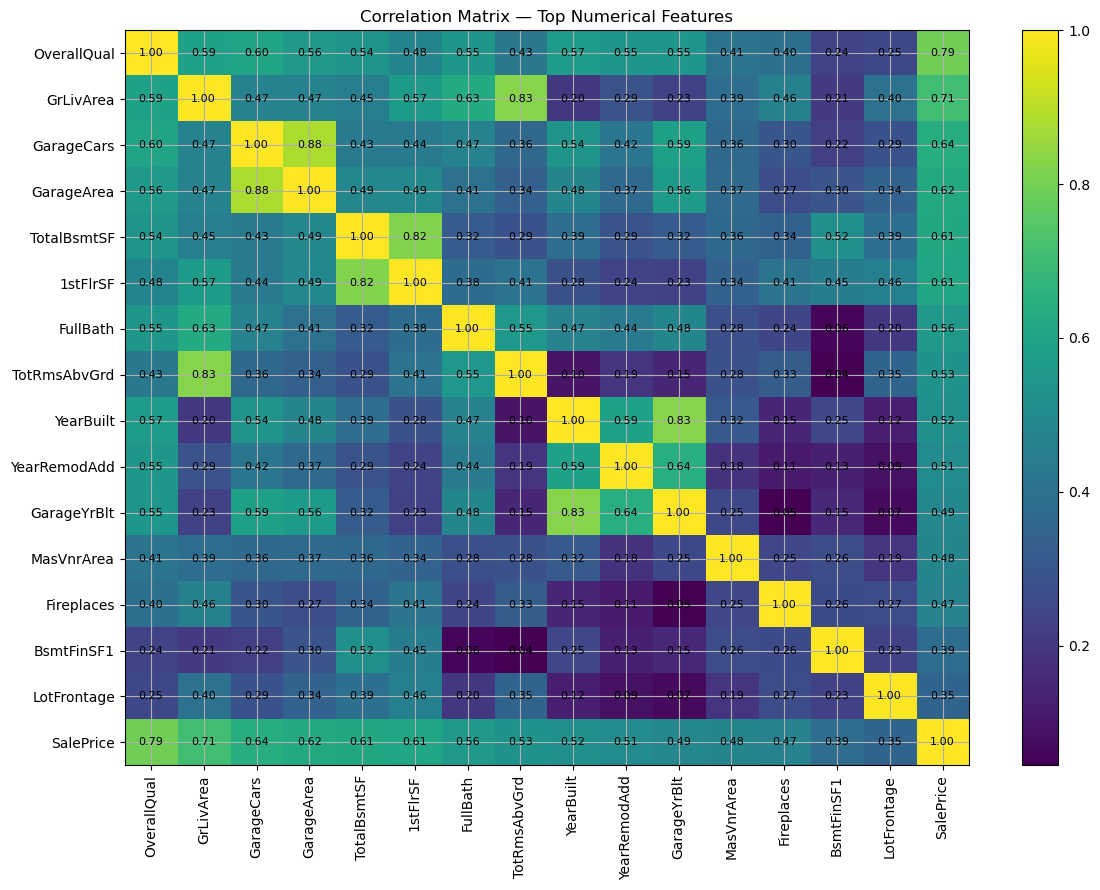

In [34]:
corr_cols = top_corr_features + [target]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr_matrix, aspect="auto")
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90)
ax.set_yticklabels(corr_cols)
ax.set_title("Correlation Matrix — Top Numerical Features")

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(
            j, i, f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center", va="center", fontsize=8
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 15. Multicollinearity and VIF

In [35]:
vif_candidates = [
    c for c in top_corr_features
    if c in df.columns and df[c].notna().all()
]

if len(vif_candidates) >= 2:
    X_vif = df[vif_candidates].copy()
    X_vif = X_vif.loc[:, X_vif.nunique() > 1]

    vif_data = pd.DataFrame({
        "feature": X_vif.columns,
        "VIF": [
            variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])
        ]
    }).sort_values("VIF", ascending=False)

    display(vif_data)
else:
    print("Not enough complete numerical features to calculate VIF.")

,feature,VIF
8,YearBuilt,"8,295.140"
9,YearRemodAdd,"8,142.316"
7,TotRmsAbvGrd,58.166
0,OverallQual,49.414
1,GrLivArea,49.220
5,1stFlrSF,37.775
2,GarageCars,34.515
3,GarageArea,29.726
4,TotalBsmtSF,26.258
6,FullBath,18.493


### VIF Interpretation

Practical screening guidelines:
- VIF ≈ 1 → little/no multicollinearity
- VIF 1–5 → moderate
- VIF > 5 → potentially important
- VIF > 10 → strong multicollinearity

These are practical guidelines rather than universal cutoffs.

## 16. Time and Seasonality Analysis

In [36]:
time_features = [
    c for c in ["MoSold", "YrSold", "YearBuilt", "YearRemodAdd"]
    if c in df.columns
]

for col in time_features:
    print(f"{col}:")
    display(df.groupby(col)[target].agg(["count", "mean", "median"]).sort_index())

MoSold:


,count,mean,median
MoSold,,,
1,58,"183,256.259","151,650.000"
2,52,"177,882.000","173,250.000"
3,106,"183,253.925","165,250.000"
4,141,"171,503.262","147,000.000"
5,204,"172,307.270","154,000.000"
6,253,"177,395.735","163,000.000"
7,234,"186,331.192","165,195.000"
8,122,"184,651.828","174,450.000"
9,63,"195,683.206","185,900.000"


YrSold:


,count,mean,median
YrSold,,,
2006,314,"182,549.459","163,995.000"
2007,329,"186,063.152","167,000.000"
2008,304,"177,360.839","164,000.000"
2009,338,"179,432.104","162,000.000"
2010,175,"177,393.674","155,000.000"


YearBuilt:


,count,mean,median
YearBuilt,,,
1872,1,"122,000.000","122,000.000"
1875,1,"94,000.000","94,000.000"
1880,4,"200,619.750","194,989.500"
1882,1,"168,000.000","168,000.000"
1885,2,"111,250.000","111,250.000"
...,...,...,...
2006,67,"251,775.448","239,799.000"
2007,49,"255,362.735","239,000.000"
2008,23,"348,849.130","335,000.000"


YearRemodAdd:


,count,mean,median
YearRemodAdd,,,
1950,178,"117,463.056","115,000.000"
1951,4,"129,975.000","138,450.000"
1952,5,"110,398.600","123,500.000"
1953,10,"147,640.000","152,250.000"
1954,14,"121,142.857","118,500.000"
1955,9,"124,511.111","130,000.000"
1956,10,"124,235.000","128,950.000"
1957,9,"132,656.444","141,000.000"
1958,15,"128,386.667","136,000.000"


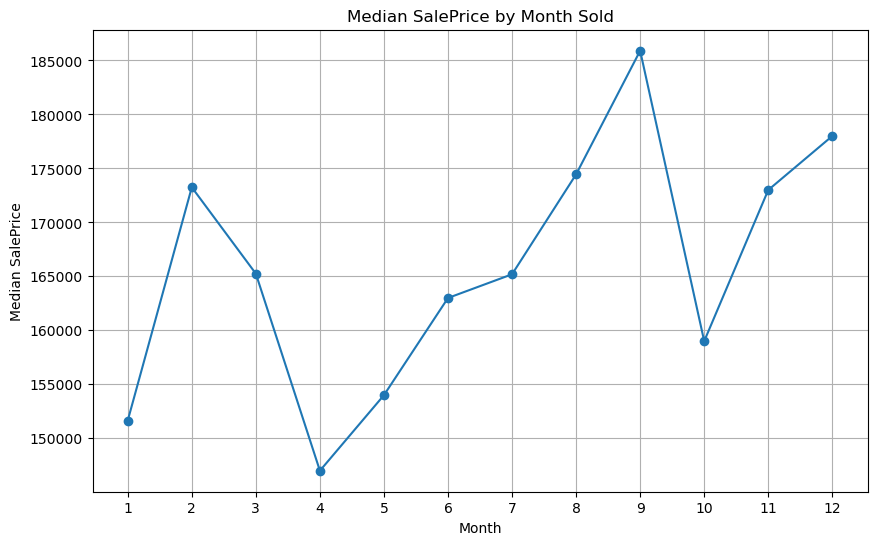

In [37]:
if "MoSold" in df.columns:
    monthly = df.groupby("MoSold")[target].agg(["count", "mean", "median"])

    fig, ax = plt.subplots()
    ax.plot(monthly.index, monthly["median"], marker="o")
    ax.set_title("Median SalePrice by Month Sold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Median SalePrice")
    ax.set_xticks(range(1, 13))
    plt.show()

### Cyclic Encoding Recommendation

Because months are cyclic:

**December → January**

are close in time even though their numerical values are far apart.

Recommended:

`sin_month = sin(2π × MoSold / 12)`

`cos_month = cos(2π × MoSold / 12)`

In [38]:
if "MoSold" in df.columns:
    df["MoSold_sin"] = np.sin(2 * np.pi * df["MoSold"] / 12)
    df["MoSold_cos"] = np.cos(2 * np.pi * df["MoSold"] / 12)

    display(df[["MoSold", "MoSold_sin", "MoSold_cos"]].head())

,MoSold,MoSold_sin,MoSold_cos
0,2,0.866,0.500
1,5,0.500,-0.866
2,9,-1.000,-0.000
3,2,0.866,0.500
4,12,-0.000,1.000


## 17. Statistical Tests

In [39]:
stats_rows = []

for col in numeric_cols:
    if col == target:
        continue

    valid = df[[col, target]].dropna()

    if valid[col].nunique() > 1:
        pearson_r, pearson_p = stats.pearsonr(valid[col], valid[target])
        spearman_r, spearman_p = stats.spearmanr(valid[col], valid[target])

        stats_rows.append({
            "feature": col,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p
        })

numeric_tests = pd.DataFrame(stats_rows).sort_values(
    "spearman_r", key=abs, ascending=False
)

display(numeric_tests.head(20))

,feature,pearson_r,pearson_p,spearman_r,spearman_p
4,OverallQual,0.791,0.000,0.810,0.000
16,GrLivArea,0.709,0.000,0.731,0.000
26,GarageCars,0.640,0.000,0.691,0.000
6,YearBuilt,0.523,0.000,0.653,0.000
27,GarageArea,0.623,0.000,0.649,0.000
19,FullBath,0.561,0.000,0.636,0.000
12,TotalBsmtSF,0.614,0.000,0.603,0.000
25,GarageYrBlt,0.486,0.000,0.594,0.000
13,1stFlrSF,0.606,0.000,0.575,0.000
7,YearRemodAdd,0.507,0.000,0.571,0.000


In [40]:
categorical_tests = []

for col in available_target_cats:
    groups = [
        group[target].dropna().values
        for _, group in df.groupby(col, dropna=True)
    ]

    groups = [g for g in groups if len(g) >= 2]

    if len(groups) >= 2:
        try:
            f_stat, anova_p = stats.f_oneway(*groups)
            h_stat, kruskal_p = stats.kruskal(*groups)

            categorical_tests.append({
                "feature": col,
                "groups": len(groups),
                "anova_p": anova_p,
                "kruskal_p": kruskal_p
            })
        except Exception:
            pass

categorical_tests = pd.DataFrame(categorical_tests).sort_values("kruskal_p")
display(categorical_tests)

,feature,groups,anova_p,kruskal_p
1,OverallQual,10,0.000,0.000
0,Neighborhood,25,0.000,0.000
2,KitchenQual,4,0.000,0.000
4,Foundation,6,0.000,0.000
3,GarageType,6,0.000,0.000
6,HouseStyle,8,0.000,0.000
5,SaleCondition,6,0.000,0.000


## 18. Feature Engineering Recommendations

In [41]:
feature_engineering_candidates = {}

if {"YrSold", "YearBuilt"}.issubset(df.columns):
    feature_engineering_candidates["HouseAge"] = "YrSold - YearBuilt"

if {"YrSold", "YearRemodAdd"}.issubset(df.columns):
    feature_engineering_candidates["RemodAge"] = "YrSold - YearRemodAdd"

if {"FullBath", "HalfBath"}.issubset(df.columns):
    feature_engineering_candidates["TotalBath"] = "FullBath + 0.5 × HalfBath"

if {"TotalBsmtSF", "1stFlrSF", "2ndFlrSF"}.issubset(df.columns):
    feature_engineering_candidates["TotalSF"] = (
        "TotalBsmtSF + 1stFlrSF + 2ndFlrSF"
    )

if {"OpenPorchSF", "3SsnPorch", "EnclosedPorch", "ScreenPorch", "WoodDeckSF"}.issubset(df.columns):
    feature_engineering_candidates["TotalPorchSF"] = (
        "OpenPorchSF + 3SsnPorch + EnclosedPorch + ScreenPorch + WoodDeckSF"
    )

binary_candidates = {
    "Has2ndFloor": "2ndFlrSF > 0",
    "HasGarage": "GarageArea > 0",
    "HasBsmt": "TotalBsmtSF > 0",
    "HasFireplace": "Fireplaces > 0",
    "HasMasVnr": "MasVnrArea > 0"
}

display(pd.DataFrame(
    list(feature_engineering_candidates.items()),
    columns=["Feature", "Definition"]
))

display(pd.DataFrame(
    list(binary_candidates.items()),
    columns=["Feature", "Definition"]
))

,Feature,Definition
0,HouseAge,YrSold - YearBuilt
1,RemodAge,YrSold - YearRemodAdd
2,TotalBath,FullBath + 0.5 × HalfBath
3,TotalSF,TotalBsmtSF + 1stFlrSF + 2ndFlrSF
4,TotalPorchSF,OpenPorchSF + 3SsnPorch + EnclosedPorch + Scre...


,Feature,Definition
0,Has2ndFloor,2ndFlrSF > 0
1,HasGarage,GarageArea > 0
2,HasBsmt,TotalBsmtSF > 0
3,HasFireplace,Fireplaces > 0
4,HasMasVnr,MasVnrArea > 0


### Example Feature Engineering Implementation

In [42]:
engineered = df.copy()

if {"YrSold", "YearBuilt"}.issubset(engineered.columns):
    engineered["HouseAge"] = engineered["YrSold"] - engineered["YearBuilt"]

if {"YrSold", "YearRemodAdd"}.issubset(engineered.columns):
    engineered["RemodAge"] = engineered["YrSold"] - engineered["YearRemodAdd"]

if {"FullBath", "HalfBath"}.issubset(engineered.columns):
    engineered["TotalBath"] = (
        engineered["FullBath"] + 0.5 * engineered["HalfBath"]
    )

if {"TotalBsmtSF", "1stFlrSF", "2ndFlrSF"}.issubset(engineered.columns):
    engineered["TotalSF"] = (
        engineered["TotalBsmtSF"]
        + engineered["1stFlrSF"]
        + engineered["2ndFlrSF"]
    )

if {"OpenPorchSF", "3SsnPorch", "EnclosedPorch", "ScreenPorch", "WoodDeckSF"}.issubset(engineered.columns):
    engineered["TotalPorchSF"] = (
        engineered["OpenPorchSF"]
        + engineered["3SsnPorch"]
        + engineered["EnclosedPorch"]
        + engineered["ScreenPorch"]
        + engineered["WoodDeckSF"]
    )

binary_conditions = {}

if "2ndFlrSF" in engineered.columns:
    binary_conditions["Has2ndFloor"] = engineered["2ndFlrSF"] > 0
if "GarageArea" in engineered.columns:
    binary_conditions["HasGarage"] = engineered["GarageArea"] > 0
if "TotalBsmtSF" in engineered.columns:
    binary_conditions["HasBsmt"] = engineered["TotalBsmtSF"] > 0
if "Fireplaces" in engineered.columns:
    binary_conditions["HasFireplace"] = engineered["Fireplaces"] > 0
if "MasVnrArea" in engineered.columns:
    binary_conditions["HasMasVnr"] = engineered["MasVnrArea"] > 0

for feature, condition in binary_conditions.items():
    engineered[feature] = condition.astype(int)

display(engineered.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MoSold_sin,MoSold_cos,HouseAge,RemodAge,TotalBath,TotalSF,TotalPorchSF,Has2ndFloor,HasGarage,HasBsmt,HasFireplace,HasMasVnr
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,0.866,0.500,5,5,2.500,2566,61,1,1,1,0,1
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,0.500,-0.866,31,31,2.000,2524,298,0,1,1,1,0
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,-1.000,-0.000,7,6,2.500,2706,42,1,1,1,1,1
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,0.866,0.500,91,36,1.000,2473,307,1,1,1,1,0
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,-0.000,1.000,8,8,2.500,3343,276,1,1,1,1,1


# 19. Final EDA Insights

### Target
- `SalePrice` is right-skewed and is a candidate for `log1p` transformation.
- Mean and median differ because of the right tail.

### Numerical Features
- `OverallQual`, `GrLivArea`, and major area/garage variables show strong relationships with price.
- Several area variables are right-skewed.
- Extreme observations should be investigated before removal.

### Missing Values
- Missingness is not always random.
- Some NaNs represent the absence of a house feature and should receive semantically meaningful treatment.

### Categorical Features
- `Neighborhood`, quality variables, and several structural categories have strong relationships with price.
- Some categories are highly imbalanced.

### Multicollinearity
- Several size and garage variables are strongly related to each other.
- VIF should be considered for linear-model workflows.

### Time
- `MoSold` may contain seasonal information.
- Cyclic encoding can represent month relationships better than raw month numbers.

### Feature Engineering
Potentially useful derived features include:
- `HouseAge`
- `RemodAge`
- `TotalBath`
- `TotalSF`
- `TotalPorchSF`
- `HasGarage`
- `HasBsmt`
- `HasFireplace`
- `Has2ndFloor`
- `HasMasVnr`

# 20. Recommended Preprocessing Plan

**Train/Validation Split**
↓  
**Structural Missing-Value Handling**
↓  
**Numerical Imputation**
↓  
**Categorical Imputation**
↓  
**Feature Engineering**
↓  
**Skewness Transformation**
↓  
**Ordinal / One-Hot Encoding**
↓  
**Scaling when required**
↓  
**Feature Selection / VIF**
↓  
**Modeling**
↓  
**Evaluation & Cross-Validation**

### Important
Target encoding must be performed inside training folds to avoid data leakage.

# 🎯 Final Takeaway

A professional EDA is not a collection of charts.

It should answer:

> **What is happening in the data? Why is it happening? What should we do about it?**

This notebook follows:

**Observation → Interpretation → Decision**

and prepares the project for:

**EDA → Preprocessing → Feature Engineering → Modeling → Evaluation → Hyperparameter Tuning**